In [1]:
!nvidia-smi

Tue Dec 24 21:43:50 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import cupy as cp
import numpy as np
from numba import cuda, types, njit
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from abc import ABC, abstractmethod
from PIL import Image


GTSRB_path = '/kaggle/input/gtsrb-german-traffic-sign'
CIFAR10_path = '/kaggle/input/cifar10-classification-image'
butterfly_species_path = '/kaggle/input/butterfly-images40-species'
brain_tumor_mri_path = '/kaggle/input/brain-tumor-mri-dataset'


os.environ['CUPY_SYNCHRONIZE'] = '1'
cpt = cp.float32
npt = np.float32
cdt = types.float32

device_id = 0
cp.cuda.Device(device_id).use()
cuda.select_device(device_id)

<weakproxy at 0x7ae626dcbb50 to Device at 0x7ae626db3580>

In [4]:
current_device_id_cp = cp.cuda.Device().id
print(f"CuPy is using device: {current_device_id_cp}")

current_device_id_numba = cuda.get_current_device().id
print(f"Numba is using device: {current_device_id_numba}")

CuPy is using device: 0
Numba is using device: 0


# Convolutional Neural Netwrok Building Blocks

### Operations

In [5]:
###################       operations        #########################

# Convolution
@cuda.jit
def convolution_kernel(input_matrix, kernels, output_matrix):
                                      # max kernel shape
    shared_kernel = cuda.shared.array((8, 8, 64), dtype=cdt)
    x, y = cuda.grid(2)
    om, oh, ow, oc = output_matrix.shape
    k, kh, kw, kd = kernels.shape
       # in_d: to use to check for broadcasting
    m, _, _, in_d = input_matrix.shape

    xt, yt = cuda.threadIdx.x, cuda.threadIdx.y
    deep = 0 if in_d == 1 else 1
    for kernel in range(k):

        if xt < kh and yt < kw:
            for zt in range(kd):
                shared_kernel[xt, yt, zt] = kernels[kernel, xt, yt, zt]

        cuda.syncthreads()
        if x < oh and y < ow:
            for img in range(om):
                result = 0
                for h in range(kh):
                    for w in range(kw):
                        for d in range(kd):
                            result += input_matrix[img, x+h, y+w, d] * shared_kernel[h, w, d]
                output_matrix[img, x, y, kernel] = result

def convolve(x, kernels, a):
    """
    input matrix should be padded
    the thicker padding parts should be up and right (if exists)
    the max kernel shape is (8, 8, 64)
    """
    _, kh, kw, kd = kernels.shape
    max_h, max_w, max_d = (8, 8, 64)
    assert kh <= max_h and kw <= max_w and kd <= max_d, f"max kernel shape exceeded with kernels shape: {kernels.shape}"
    m, h, w, c = a.shape

    threads_per_block_x = threads_per_block_y = 16
    blocks_per_grid_x = (h + threads_per_block_x - 1) // threads_per_block_x
    blocks_per_grid_y = (w + threads_per_block_y - 1) // threads_per_block_y

    threads = (threads_per_block_x, threads_per_block_y)
    blocks = (blocks_per_grid_x, blocks_per_grid_y)

    convolution_kernel[blocks, threads](x, kernels, a)
    cp.cuda.Device().synchronize()


# max pooling
@cuda.jit
def max_pool_kernel(input_matrix, pool_shape, output_matrix, mask):
    x, y , z= cuda.grid(3)
    m, h, w, d = output_matrix.shape
    if x < h and y < w and z < d:
        ph, pw = pool_shape
        xi, xj = x * ph, y * pw
        max_i, max_j = xi, xj
        for img in range(m):
            max_value = input_matrix[img, xi, xj, z]
            max_i, max_j = 0, 0
            for i in range(ph):
                for j in range(pw):
                    temp = input_matrix[img, xi+i, xj+j, z]
                    if temp > max_value:
                        max_value = temp
                        max_i, max_j = i, j
            mask[img, xi+max_i, xj+max_j, z] = 1
            output_matrix[img, x, y, z] = max_value


def max_pool(input_matrix, pool_shape, output_matrix, mask):
    m, h, w, d = output_matrix.shape
    assert input_matrix.shape[1] / pool_shape[0] == h and input_matrix.shape[2] / pool_shape[1] == w, \
    f"input, pool, ouput matrices shape mismatch {input_matrix.shape}, {pool_shape}, {output_matrix.shape}"
    threads_per_block_x = 8
    threads_per_block_y = 8
    threads_per_block_z = 8

    blocks_per_grid_x = (output_matrix.shape[1] + threads_per_block_x - 1) // threads_per_block_x
    blocks_per_grid_y = (output_matrix.shape[2] + threads_per_block_y - 1) // threads_per_block_y
    blocks_per_grid_z = (output_matrix.shape[3] + threads_per_block_z - 1) // threads_per_block_z

    threads = (threads_per_block_x, threads_per_block_y, threads_per_block_z)
    blocks = (blocks_per_grid_x, blocks_per_grid_y, blocks_per_grid_z)

    max_pool_kernel[blocks, threads](input_matrix, pool_shape, output_matrix, mask)
    cp.cuda.Device().synchronize()



@cuda.jit
def distribution_kernel(input_matrix, pool_shape, output_matrix):
    """
    each thread copies certain value in the input shape into a 2D pool in the output matrix
    """
    m, h, w, d = input_matrix.shape
    x, y, z = cuda.grid(3)
    om, oh, ow, od = output_matrix.shape
    if x < h and y < w and z < d:
        ph, pw = pool_shape
        xi, xj = x * ph, y * pw
        for img in range(m):
            for i in range(ph):
                for j in range(pw):
                    if xi + i < oh and xj + j < ow:
                        output_matrix[img, xi + i,xj + j, z] = input_matrix[img, xi, xj, z]


def distribute(dz, pool_shape, output_matrix):
    ph, pw = pool_shape
    threads_per_block_x = ph
    threads_per_block_y = pw
    threads_per_block_z = 32

    blocks_per_grid_x = (dz.shape[1] + threads_per_block_x - 1) // threads_per_block_x
    blocks_per_grid_y = (dz.shape[2] + threads_per_block_y - 1) // threads_per_block_y
    blocks_per_grid_z = (dz.shape[3] + threads_per_block_z - 1) // threads_per_block_z

    threads = (threads_per_block_x, threads_per_block_y, threads_per_block_z)
    blocks = (blocks_per_grid_x, blocks_per_grid_y, blocks_per_grid_z)

    distribution_kernel[blocks, threads](dz, pool_shape, output_matrix)
    cp.cuda.Device().synchronize()

# ##########################################  operations  #############################################

### Layers

In [6]:
#####################################  Base-Layer & Activation  #####################################
class Activation:
    def __init__(self, formula, derivative):
        self.formula = formula
        self.derivative = derivative


class Layer(ABC):
    ReLU = Activation(
        formula=lambda x: cp.maximum(x, 0),
        derivative=lambda x: x > 0
    )

    gradient_scaling_factor = 10
    gradient_norm_threshold = float('inf')
    min_threshold = 1e-9
    max_threshold = 120
    def softmax_formula(z):
        z = z - cp.max(z, axis=1, keepdims=True)
        exp_z = cp.exp(z)
        exp_sum = cp.sum(exp_z, axis=1, keepdims=True)
        return exp_z / exp_sum

    Softmax = Activation(
        formula=softmax_formula,
        derivative=lambda x: Exception("you shouldn't calculate the derviate of the softmax activation function in this version")
    )


    def clip(self, a):
      pass
      if cp.isnan(a).any():
        mn = cp.nan_to_num(a[:], nan=cp.nanmean(a))

      clipper(a, self.min_threshold, self.max_threshold)



    @abstractmethod
    def init_params(self, input_shape, index=None):
        pass

    @abstractmethod
    def forward_prop(self, x, a):
        pass

    @abstractmethod
    def back_prop(self, dz_in, x, a, dz_out):
        pass


    @abstractmethod
    def update_params(self, alpha, beta_1, beta_2, epsilon):
        pass

#####################################  Base-Layer & Activation  #####################################

In [7]:
#############################################  Layers  ##############################################
class Fully_Connected(Layer):
    def __init__(self, nodes, activation=Layer.ReLU, index=None):
        self.nodes = nodes
        self.activation = activation
        self.index = index
        self.t = 1

    def init_params(self, input_shape):
        if self.activation == Layer.Softmax:
            stdv = cp.sqrt(1 / input_shape)
        else :
            stdv = cp.sqrt(2 / input_shape)
        self.w = cp.random.randn(input_shape, self.nodes, dtype=cpt) * stdv
        self.b = cp.random.rand(1, self.nodes, dtype=cpt) * 0.1

        self.vw = cp.zeros_like(self.w, dtype=cpt)
        self.sw = cp.zeros_like(self.w, dtype=cpt)

        self.vb = cp.zeros_like(self.b, dtype=cpt)
        self.sb = cp.zeros_like(self.b, dtype=cpt)

        return self.nodes

    def forward_prop(self, x, a):
        a[:] = self.activation.formula(x @ self.w + self.b)

    def back_prop(self, dz_in, x, a):
        m = 1 / x.shape[0]

        if self.activation is not Layer.Softmax:
            dz_in *= self.activation.derivative(a)

        self.dw = m * (x.T @ dz_in)
        self.db = m * cp.sum(dz_in, axis=0).reshape(1, -1)
        dz_out = dz_in @ self.w.T
        return dz_out


    def update_params(self, alpha, beta_1, beta_2, epsilon):
        """
        - alpha is the learning rate
        - beta_1 is the exponential average of the first momentum
        - beta_2 is the exponential average of the second momentum
        - epsilon is used to avoid division by zero
        """
        if self.gradient_norm_threshold != float('inf'):
            dw_norm = cp.sqrt(cp.sum(self.dw**2))
            if dw_norm > self.gradient_norm_threshold:
                self.dw *= self.gradient_norm_threshold / dw_norm

            db_norm = cp.sqrt(cp.sum(self.db**2))
            if db_norm > self.gradient_norm_threshold:
                self.db *= self.gradient_norm_threshold / db_norm


        self.vw = beta_1 * self.vw + (1-beta_1) * self.dw
        self.sw = beta_2 * self.sw + (1-beta_2) * (self.dw * self.dw)

        vw_corrected = self.vw / (1 - beta_1 ** self.t)
        sw_corrected = self.sw / (1 - beta_2 ** self.t)

        self.w = self.w - alpha * (vw_corrected) # / (cp.sqrt(vw_corrected) + epsilon))

        self.vb = beta_1 * self.vb + (1-beta_1) * self.db
        self.sb = beta_2 * self.sb + (1-beta_2) * (self.db * self.db)

        vb_corrected = self.vb / (1 - beta_1 ** self.t)
        sb_corrected = self.sb / (1 - beta_2 ** self.t)

        self.b = self.b - alpha * (vb_corrected) # / (cp.sqrt(sb_corrected) + epsilon))

        del sw_corrected, vw_corrected, sb_corrected, vb_corrected

        self.t += 1


    def __repr__(self):
        return f"{self.__class__.__name__}{self.index if self.index is not None else ''}: {self.nodes} nodes"


In [8]:
class Conv(Layer):
    def __init__(self, kernels, kernel_shape=(3, 3), activation=None):
        self.kernels = kernels
        self.activation = activation
        self.kernel_shape = kernel_shape if len(kernel_shape) == 3 else (*kernel_shape, 3)
        self.t = 1

    def init_params(self, input_shape):
        output_depth = input_shape[2] if len(input_shape) == 3 else 3
        fan_in = self.kernel_shape[0] * self.kernel_shape[1] * self.kernel_shape[2]

        kh, kw, kd = self.kernel_shape
        pu = kh//2
        pd = kh//2 - int(kh%2==0)
        pr = kw//2
        pl = kw//2 - int(kw%2==0)
        self.padding = ((0, 0), (pu, pd), (pr, pl), (0, 0))

        output_shape = (*input_shape[:-1], self.kernels)
        fan_out = output_shape[0] * output_shape[1] * output_shape[2]
        stdv = cp.sqrt(2/fan_in) # + fan_out)
        self.kernels = cp.random.randn(self.kernels, *self.kernel_shape, dtype=cpt) * stdv
        self.b = cp.random.rand(1, *output_shape, dtype=cpt) * 0.1

        self.vk = cp.zeros_like(self.kernels, dtype=cpt)
        self.sk = cp.zeros_like(self.kernels, dtype=cpt)

        self.vb = cp.zeros_like(self.b, dtype=cpt)
        self.sb = cp.zeros_like(self.b, dtype=cpt)


        return output_shape

    def forward_prop(self, x, a):


        if len(x.shape) == len(self.kernel_shape):
            x = cp.expand_dims(x, axis=0)

        m, xh, xw, xc = x.shape
        convolve(cp.pad(x, self.padding), self.kernels, a)
        a[:] = a + self.b
        if self.activation is not None:
            a[:] = self.activation.formula(a)
            self.mask = a > 0


    def back_prop(self, dz, x, a):
        kh, kw, kd = self.kernel_shape
        m, xh, xw, xc = x.shape
        n, dzh, dzw, dzc = dz.shape
        if self.activation is not None:
            dz = dz * self.mask
            del self.mask
        self.db = cp.mean(dz, axis=0)
        self.dk = cp.zeros_like(self.kernels, dtype=cpt)

        # dk
        kh_center = kh//2
        kw_center = kw//2
        for k in range(dzc):
            for i in range(kh):
                for j in range(kw):
                    i_start = max(0, kh_center-i)
                    i_end = xh - max(0, i - kh_center)
                    j_start = max(0, kw_center-j)
                    j_end = xw - max(0, j - kw_center)

                    x_slice = x[:, i_start:i_end, j_start:j_end, :]
                    dz_slice = dz[:, i_start: i_end, j_start: j_end, k: k+1]

                    self.dk[k, i, j, :] = cp.sum(x_slice * dz_slice, axis=(0, 1, 2)) / m

        dz_out = cp.zeros_like(x)
        dz = cp.pad(dz, self.padding)

        flipped_kernels = cp.flip(self.kernels, axis=(1, 2))
        for k in range(len(self.kernels)):
            dz_depth_slice = dz[:, :, :, k:k+1]
            convolve(dz_depth_slice, flipped_kernels[k:k+1], dz_out)

        return dz_out


    def update_params(self, alpha, beta_1, beta_2, epsilon):
        if self.gradient_norm_threshold != float('inf'):
            dk_norm = cp.sqrt(cp.sum(self.dk**2))
            if dk_norm > self.gradient_norm_threshold:
                self.dk *= self.gradient_norm_threshold / dk_norm

            db_norm = cp.sqrt(cp.sum(self.db**2))
            if db_norm > self.gradient_norm_threshold:
                self.db *= self.gradient_norm_threshold / db_norm


        self.vk = beta_1 * self.vk + (1-beta_1) * self.dk
        self.sk = beta_2 * self.sk + (1-beta_2) * (self.dk ** 2)

        vk_corrected = self.vk / (1 - beta_1 ** self.t)
        sk_corrected = self.sk / (1 - beta_2 ** self.t)

        self.vb = beta_1 * self.vb + (1-beta_1) * self.db
        self.sb = beta_2 * self.sb + (1-beta_2) * (self.db ** 2)

        vb_corrected = self.vb / (1 - beta_1 ** self.t)
        sb_corrected = self.sb / (1 - beta_2 ** self.t)


        self.kernels = self.kernels - alpha * vk_corrected / (cp.sqrt(sk_corrected) + epsilon)
        self.b = self.b - alpha * vb_corrected / (cp.sqrt(sb_corrected) + epsilon)
        del sk_corrected, vk_corrected, sb_corrected, vb_corrected


    def __repr__(self):
        return f"{self.__class__.__name__}{self.index if self.index is not None else ''}: {self.kernel_shape} shaped kernels"



    def visualize_kernel(self, kernel_idx):
        kernel = self.kernels[kernel_idx]

        if kernel.shape[-1] == 3:
            # For RGB kernels
            plt.imshow(cp.asnumpy(kernel))
        else:
            # For other kernel depths, show as heatmap
            plt.imshow(cp.asnumpy(cp.mean(kernel, axis=-1)), cmap='viridis')

        plt.title(f'Kernel {kernel_idx}')
        plt.colorbar()
        plt.axis('off')
        plt.show()

    def visualize_all_kernels(self, n_kernels=None):
        if n_kernels is None:
            n_kernels = len(self.kernels)

        n_cols = 4
        n_rows = (n_kernels + n_cols - 1) // n_cols
        plt.figure(figsize=(15, 3 * n_rows))

        for i in range(min(n_kernels, len(self.kernels))):
            plt.subplot(n_rows, n_cols, i + 1)
            if self.kernels.shape[-1] == 3:
                plt.imshow(cp.asnumpy(self.kernels[i]))
            else:
                plt.imshow(cp.asnumpy(cp.mean(self.kernels[i], axis=-1)), cmap='viridis')
            plt.title(f'Kernel {i}')
            plt.axis('off')

        plt.tight_layout()
        plt.show()


In [9]:
class Pool(Layer):
    def __init__(self, pool_shape=(2, 2)):
        self.pool_shape = pool_shape

    def init_params(self, input_shape):
        h, w, c = input_shape
        ph, pw = self.pool_shape

        vertical_padding = (ph - h%ph)%ph
        padding_up = vertical_padding // 2
        padding_down = vertical_padding - padding_up

        horizental_padding = (ph - w%pw)%pw
        padding_right = horizental_padding // 2
        padding_left = horizental_padding - padding_right
        self.padding = (
            (0, 0),
            (padding_up, padding_down),
            (padding_right, padding_left),
            (0, 0)
        )
        return h//ph, w//pw, c


    def forward_prop(self, x, a):
        ph, pw = self.pool_shape
        m, xh, xw, xc = x.shape

        x = cp.pad(x, self.padding)
        m, xh, xw, xc = x.shape
        self.max_mask = cp.zeros_like(x)

        max_pool(x, self.pool_shape, a, self.max_mask)

    def back_prop(self, dz, x, a):
        x = cp.pad(x, self.padding)

        distributed_dz = cp.zeros_like(x)
        distribute(dz, self.pool_shape, distributed_dz)
        return distributed_dz * self.max_mask


    def update_params(self, alpha, beta_1, beta_2, epsilon):
        pass


    def __repr__(self):
        return f"{self.__class__.__name__}{self.index if self.index is not None else ''}: {self.pool_shape} shaped pool"


In [10]:
class Flatten(Layer):
    def __init__(self):
        pass

    def init_params(self, input_shape):
        self.tensor_shape = input_shape
        output_shape = 1
        for dim in input_shape:
            output_shape *= dim

        return output_shape

    def forward_prop(self, x, a):
        a[:] = x.reshape(len(x), -1)


    def back_prop(self, dz, x, a):
        return dz.reshape(-1, *self.tensor_shape)


    def update_params(self, alpha, beta_1, beta_2, epsilon):
        pass

    def __repr__(self):
        return f"{self.__class__.__name__}{self.index if self.index is not None else ''}: {self.tensor_shape} tenshor shape"

#############################################  Layers  ##############################################

### Neural Network

In [11]:
max_threshold = float('inf')
class CNN:
    def __init__(self, *layers, input_shape=None):
        self.layers = layers
        self.depth = len(layers)
        self.feature_shapes = [input_shape]
        for index, layer in enumerate(self.layers):
            layer.index = index + 1
            input_shape = layer.init_params(input_shape)
            self.feature_shapes.append(input_shape)
        self.beta_1 = cp.array(0.9)
        self.beta_2 = cp.array(0.999)
        self.epsilon = cp.array(0.1)

        print(f"[INFO] model parameters initialized successfully !")

    def allocate_mem(self, batch_size, test_size):
        self.features = []
        self.test_features = []
        for feature_shape in self.feature_shapes:
            if type(feature_shape) == int:
                self.features.append(cp.empty((batch_size, feature_shape), dtype=cpt))
            else :
                self.features.append(cp.empty((batch_size, *feature_shape), dtype=cpt))

        for feature_shape in self.feature_shapes:
            if type(feature_shape) == int:
                self.test_features.append(cp.empty((test_size, feature_shape), dtype=cpt))
            else :
                self.test_features.append(cp.empty((test_size, *feature_shape), dtype=cpt))

    def forward_prop(self, x, test=False):
        if test:
            self.test_features[0][:] = x
            for i, layer in enumerate(self.layers):
                if cp.isnan(x).any():
                    raise Exception(f"forward: nan values in x at layer: {layer}")
                layer.forward_prop(self.test_features[i], self.test_features[i+1])
            return self.test_features[-1]

        else:
            self.features[0][:] = x
            for i, layer in enumerate(self.layers):
                if cp.isnan(x).any():
                    raise Exception(f"forward test nan values in x at layer: {layer}")
                layer.forward_prop(self.features[i], self.features[i+1])
            return self.features[-1]


    def cross_entropy(self, y, y_pred):
        return (y_pred - y)*self.class_weights

    def accuracy(self, y, y_pred):
        y = cp.argmax(y, axis=1)
        y_pred = cp.argmax(y_pred, axis=1)
        return 100 * cp.sum(y_pred == y) / y.shape[0]

    def back_prop(self, dz):
        for index, layer in enumerate(self.layers[::-1]):
            dz = cp.clip(dz, -max_threshold, max_threshold)
            if cp.isnan(dz).any():
                dz = cp.nan_to_num(dz, nan=0)
                print(layer.__class__.__name__, 'nan')
            if layer.gradient_norm_threshold != float('inf'):
                gradient_norm = cp.sqrt(cp.sum(dz ** 2))
                if gradient_norm > layer.gradient_norm_threshold:
                    dz *= layer.gradient_norm_threshold / gradient_norm
            a = self.features[self.depth-index]
            x = self.features[self.depth-index-1]
            dz = layer.back_prop(dz, x, a)




    def optimize(self, x_train, y_train, x_test, y_test, epochs=8, batch_size=32, learning_rate=0.001, class_weights=None, mem_tracker=None, conv_grad_norm_threshold=float('inf'), fc_grad_norm_threshold=float('inf')):
        if class_weights is None:
            class_weights = cp.ones((1, y_train.shape[1]))
        self.class_weights = cp.array(class_weights)

        Conv.gradient_norm_threshold = conv_grad_norm_threshold
        Fully_Connected.gradient_norm_threshold = fc_grad_norm_threshold


        m = len(x_train)

        self.allocate_mem(batch_size, len(x_test))
        batchs = len(x_train) // batch_size
        for epoch in range(1, epochs+1):
            mem = []
            cp.get_default_memory_pool().free_all_blocks()
            for batch in tqdm(range(batchs-1)):
                a = batch * batch_size
                if mem_tracker is not None and not batch % (batchs//mem_tracker):
                    mem.append(f"{cp.get_default_memory_pool().used_bytes() / (1024 * 1024):.2f} MB")

                b = min((batch+1)*batch_size, m)
                if (b-a) == batch_size:
                    x = cp.array(x_train[a:b])
                    y = cp.array(y_train[a:b])

                    cp.cuda.Device().synchronize()
                    cuda.synchronize()

                    y_pred = self.forward_prop(x)

                    loss = self.cross_entropy(y, y_pred)

                    cp.cuda.Device().synchronize()
                    cuda.synchronize()

                    self.back_prop(loss)

                    cp.cuda.Device().synchronize()
                    cuda.synchronize()


                    for layer in self.layers:
                        layer.update_params(learning_rate, self.beta_1, self.beta_2, self.epsilon)

            print(f"[INFO] epoch {epoch}/{epochs} accuracy: {self.accuracy(y, self.forward_prop(x)):.8f} | val_accuracy: {self.accuracy(cp.array(y_test), self.forward_prop(cp.array(x_test), test=True)):.8f}")
            if mem_tracker is not None:
                mem.append(f"{cp.get_default_memory_pool().used_bytes() / (1024 * 1024):.2f} MB")
                print(f"memory usage: {mem}")


    def predict(self, x):
        if len(x.shape) == 3:
            x = cp.expand_dims(x, axis=0)

        for i, layer in enumerate(self.layers):
            if isinstance(self.feature_shapes[layer.index], int):
                output_shape = (len(x), self.feature_shapes[layer.index])
            else:
                output_shape = (len(x), *self.feature_shapes[layer.index])
            a = cp.zeros(output_shape)
            layer.forward_prop(x, a)
            x = a
        return x

    def evaluate(self, x_test, y_test):
        y_pred = self.predict(x_test)
        print(y_pred.shape)
        return self.accuracy(y_pred, y_test)

    def plot_kernels(self, num_kernels, layer_index=0, cmap="viridis"):
        plt.figure()
        kernels = self.layers[layer_index].kernels[:num_kernels]
        r, c = num_kernels // 4, 4
        for i in range(num_kernels):
            plt.subplot(r, c, i+1)
            if kernels.shape[-1] == 3:
                img = cp.sum(kernels[i], axis=-1).get()
                mx, mn = cp.max(img), cp.min(img)
                plt.imshow(img)

            else:
                img = cp.sum(kernels[i], axis=-1).get()
                mx, mn = cp.max(img), cp.min(img)
                plt.imshow((img-mn)/(mx-mn), cmap=cmap)
            plt.title(f"kernel{i+1}/ {num_kernels}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()



    def plot_feature_map(self, images, num_kernels=4, layer_index=0, cmap="viridis"):
        x = cp.array(images)
        kernels = self.layers[layer_index].kernels[:num_kernels]
        for i, layer in enumerate(self.layers[:layer_index+1]):
            if type(self.feature_shapes[i+1]) == int:
                output_shape = (len(x), self.feature_shapes[i+1])
            else :
                output_shape = (len(x), *self.feature_shapes[i+1])
            a = cp.zeros(output_shape)
            layer.forward_prop(x, a)
            x = a

        figure, axes = plt.subplots(len(images), num_kernels+1, figsize=(16, 24))
        for i in range(len(images)):
            image = images[i]
            ax = axes[i, 0]
            ax.imshow(image)
            for k in range(num_kernels):
                ax = axes[i, k+1]
                feature_map = a[i, :, :, k].get()
                im = ax.imshow(feature_map, cmap=cmap)
                plt.axis('off')

        plt.colorbar(im)
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        plt.suptitle(f"Convolution layer {layer_index}")
        plt.show()




    def grad_cam(self, images, target_class, layer_index=0, cmap="viridis"):
        images = cp.array(images)
        target_class = cp.array(target_class)
        if len(target_class.shape) == 1:
            target_class = cp.expand_dims(target_class, axis=0)

        if len(images.shape) == 3:
            images = cp.expand_dims(images, axis=0)
        x = images
        feature_storage = [x]

        for i, layer in enumerate(self.layers):
            if isinstance(self.feature_shapes[layer.index], int):
                output_shape = (len(images), self.feature_shapes[layer.index])
            else:
                output_shape = (len(images), *self.feature_shapes[layer.index])
            a = cp.zeros(output_shape)
            layer.forward_prop(x, a)
            x = a
            feature_storage.append(x.copy())

            if i == layer_index:
                target_feature_maps = x.copy()
        final_output = feature_storage[-1]
        dz = self.cross_entropy(final_output, target_class)

        for i, layer in enumerate(self.layers[::-1]):
            if i == len(self.layers) - layer_index - 1:
                break
            curr_features = feature_storage[len(self.layers)-i]
            prev_features = feature_storage[len(self.layers)-i-1]
            dz = layer.back_prop(dz, prev_features, curr_features)

        if self.layers[layer_index].activation is not None:
            dz *= self.layers[layer_index].mask
        weights = cp.mean(dz, axis=(1, 2))
        weighted_features = weights[:, None, None, :] * target_feature_maps
        heatmaps = cp.mean(weighted_features, axis=-1)
        heatmaps = cp.maximum(heatmaps, 0)
        heatmaps = heatmaps / (cp.max(heatmaps) + 1e-10)
        heatmaps = heatmaps.get()
        plt.figure(figsize=(20, 8))
        n_images = len(heatmaps)


        fig, axes = plt.subplots(3, n_images, figsize=(20, 12))
        for idx, heatmap in enumerate(heatmaps):
            heatmap_np = cp.asnumpy(heatmaps[idx])
            heatmap_np = (heatmap_np * 255).astype(np.uint8)

            image = images[idx]

            heatmap_img = Image.fromarray(heatmap_np)
            heatmap_img = heatmap_img.resize((image.shape[1], image.shape[0]), Image.BILINEAR)

            ax = axes[0, idx]
            ax.imshow(cp.asnumpy(images[idx]))
            if idx == n_images//2:
                ax.set_title(f"Original Image {idx + 1}")
            ax.axis("off")

            ax = axes[1, idx]
            ax.imshow(heatmaps[idx], cmap=cmap)  # Replace `cmap` as desired
            if idx == n_images//2:
                ax.set_title(f"Grad-CAM Heatmap {idx + 1}")
            ax.axis("off")

            ax = axes[2, idx]
            ax.imshow(cp.asnumpy(images[idx]))
            ax.imshow(heatmaps[idx], cmap=cmap, alpha=0.4)  # Overlay with transparency
            if idx == n_images//2:
                ax.set_title(f"Grad-CAM Overlay {idx + 1}")
            ax.axis("off")

        plt.subplots_adjust(wspace=0.1, hspace=0.2)
        plt.suptitle('Gradient CAM Visualization')
        plt.tight_layout()
        plt.show()


# Data Sets

## Data Loading Procedures

In [12]:
def load_data(path, keep_weights=False, threshold=float('inf')):
    if keep_weights:
        class_weights = []

    def one_hot(y):
        one_hot_y = np.zeros((len(y), num_classes))
        one_hot_y[np.arange(len(y)), y] = 1
        return one_hot_y

    x = []
    y = []
    class_id = -1

    for subfolder in tqdm(list(os.listdir(path))):
        subfolder_path = os.path.join(path, subfolder)
        if keep_weights:
            w = len(os.listdir(subfolder_path))
            class_weights.append(w)
        class_id += 1
        images = 0
        for image in os.listdir(subfolder_path):
            images += 1
            if images > threshold:
                print(f"class {class_id}: {subfolder} Still got more iamges beyond threshold !")
                break
            image_file = os.path.join(subfolder_path, image)
            image = Image.open(image_file)
            x.append(np.array(image.resize((H, W))))
            y.append(class_id)

    x, y = np.array(x), np.array(y)
    permutation = np.random.permutation(len(x))
    x = x[permutation] / 255.0
    y = one_hot(y[permutation])
    if keep_weights:
        return class_weights, x, y
    return x, y


def split(x, y, ratio=0.8):
    threshold = int(len(x)*ratio)
    return x[0:threshold], y[0:threshold], x[threshold:], y[threshold:]

def plot_classes_distribution(path, key=str, color="indianred"):
    distribution = []
    classes = []
    for label in sorted(list(os.listdir(path)), key=key):
        distribution.append(len(os.listdir(os.path.join(path, label))))
        classes.append(label)
    plt.figure(figsize=(8, 6))
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.bar(classes, distribution, color=color)
    plt.show()

## German Traffic Signs Data Set

### fetching & splitting data

In [15]:
path = GTSRB_path
os.listdir(path)

['Meta',
 'meta',
 'Meta.csv',
 'Train.csv',
 'Test.csv',
 'Test',
 'test',
 'Train',
 'train']

In [16]:
train_path = os.path.join(path, 'Train')
test_path = os.path.join(path, 'Test')
len(os.listdir(train_path)), len(os.listdir(test_path))

(43, 12631)

In [17]:
H = W = 40
C = 3
num_classes = len(os.listdir(train_path))
class_weights, x, y = load_data(train_path, keep_weights=True)

x_train, y_train, x_test, y_test = split(x, y, ratio=0.7)
x_test, y_test, x_val, y_val = split(x_test, y_test, ratio=0.5)

100%|██████████| 43/43 [03:22<00:00,  4.71s/it]


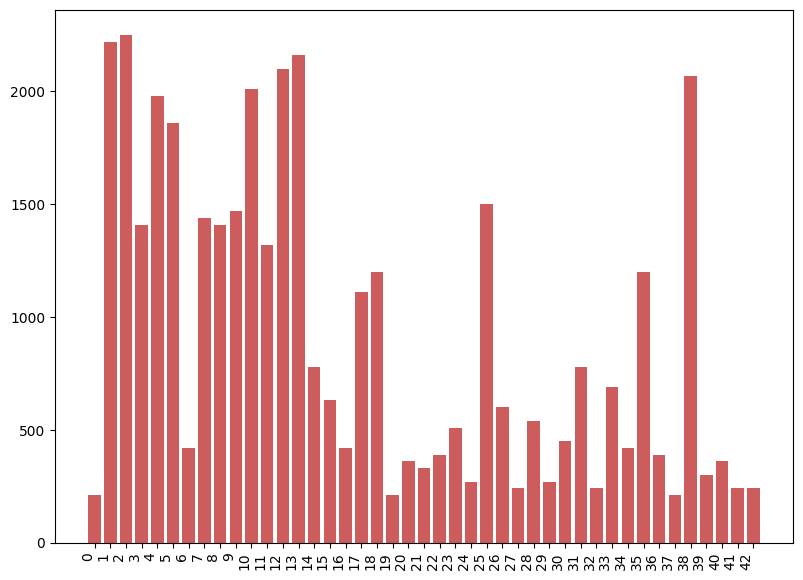

In [18]:
plot_classes_distribution(train_path, key=int)

In [19]:
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((27446, 40, 40, 3),
 (5881, 40, 40, 3),
 (5882, 40, 40, 3),
 (27446, 43),
 (5881, 43),
 (5882, 43))

In [20]:
np.argmax(y_train[:12], axis=1)

array([15, 29,  4, 18,  8,  1, 18,  4, 18, 33, 29, 15])

In [21]:
num_classes

43

In [22]:
class_weights = (len(x) / num_classes) / np.array(class_weights).reshape(1, -1)
s_class_weights = Layer.Softmax.formula(cp.array(class_weights)).get() * np.sqrt(class_weights.shape[-1])
s_class_weights = s_class_weights + (np.mean(class_weights) - np.mean(s_class_weights)) * 0.8
class_weights, s_class_weights

(array([[0.63322028, 0.82147496, 4.34208195, 2.33804413, 0.40526098,
         0.75986434, 1.7879161 , 0.45365035, 0.49023506, 2.33804413,
         2.53288114, 3.79932171, 3.79932171, 3.03945736, 3.79932171,
         0.60789147, 3.79932171, 0.64669306, 0.44050107, 0.43420819,
         4.34208195, 1.16902206, 2.17104097, 0.75986434, 1.68858742,
         2.17104097, 0.42214686, 1.51972868, 1.44736065, 0.64669306,
         0.41073748, 2.02630491, 1.16902206, 0.46052384, 0.62029742,
         2.76314306, 2.53288114, 2.17104097, 0.69078576, 4.34208195,
         1.3234212 , 3.37717485, 3.37717485]]),
 array([[1.36451166, 1.36847748, 2.12664401, 1.45067451, 1.36060897,
         1.36709655, 1.406116  , 1.3613647 , 1.36196084, 1.45067451,
         1.47332771, 1.79939947, 1.79939947, 1.55773109, 1.79939947,
         1.36403281, 1.79939947, 1.36477135, 1.3611557 , 1.36105665,
         2.12664401, 1.37808235, 1.43447776, 1.36709655, 1.4003718 ,
         1.43447776, 1.36086854, 1.39182547, 1.38858208

### Model build & train

In [23]:
cnn_with_pooling = CNN(
    Conv(64, kernel_shape=(3, 3, 3)),
    Pool(pool_shape=(2, 2)),
    Flatten(),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(num_classes, Layer.Softmax),
    input_shape=(H, W, C)
)

[INFO] model parameters initialized successfully !


In [24]:
cnn_with_pooling.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=6,
    batch_size=32,
    learning_rate=0.001,
    class_weights=s_class_weights
)

  0%|          | 0/856 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 72 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
100%|██████████| 856/856 [02:42<00:00,  5.25it/s]


[INFO] epoch 1/6 accuracy: 53.12500000 | val_accuracy: 47.70486229


100%|██████████| 856/856 [02:29<00:00,  5.73it/s]


[INFO] epoch 2/6 accuracy: 59.37500000 | val_accuracy: 63.22679361


100%|██████████| 856/856 [02:29<00:00,  5.74it/s]


...

[INFO] epoch 4/6 accuracy: 71.87500000 | val_accuracy: 75.39952397


100%|██████████| 856/856 [02:29<00:00,  5.73it/s]


[INFO] epoch 5/6 accuracy: 75.00000000 | val_accuracy: 79.15674940


100%|██████████| 856/856 [02:29<00:00,  5.71it/s]


[INFO] epoch 6/6 accuracy: 81.25000000 | val_accuracy: 82.13192792


In [92]:
a = 42
b = a + 12
images = x_test[a:b]
labels = y_test[a:b]

In [97]:
len(x_test)

5881

In [121]:
a = 1212
b = a + 12
images = x_test[a:b]
labels = y_test[a:b]

<Figure size 2000x800 with 0 Axes>

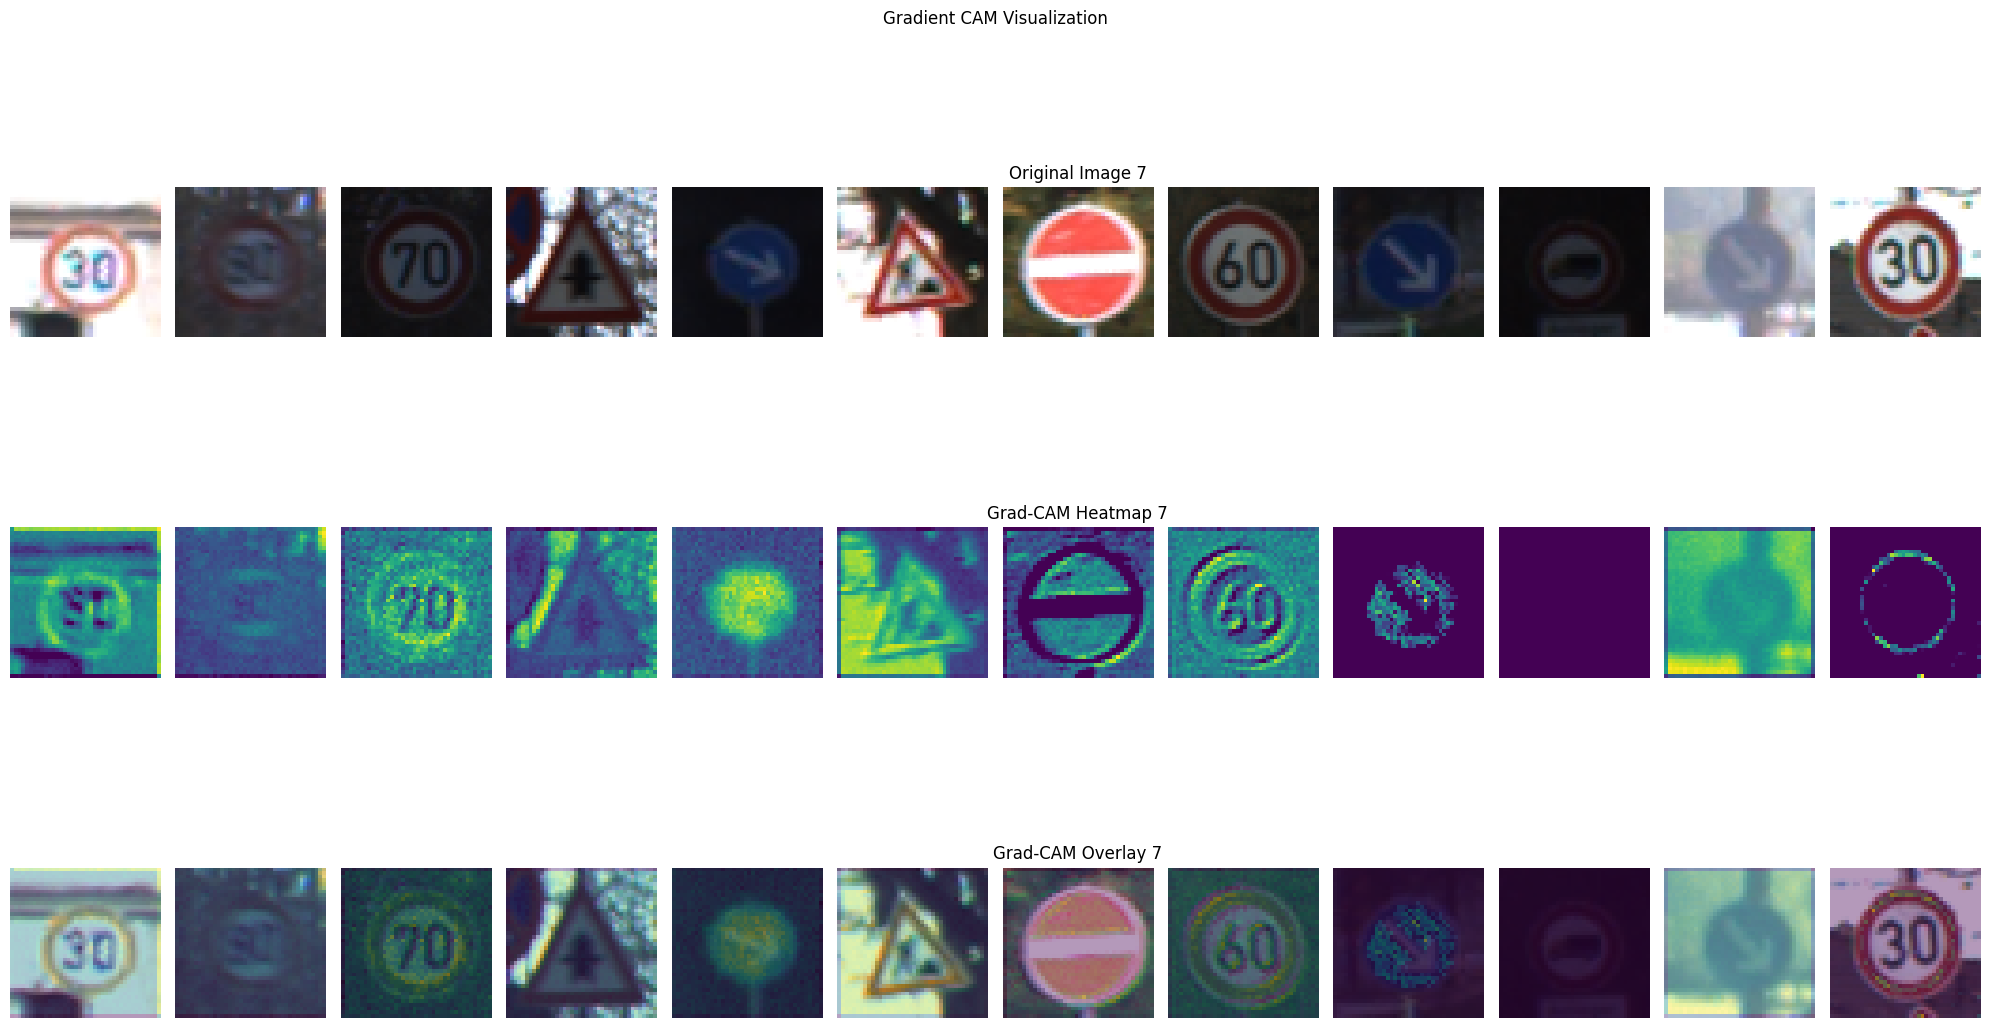

In [126]:
cnn_with_pooling.grad_cam(images, labels)

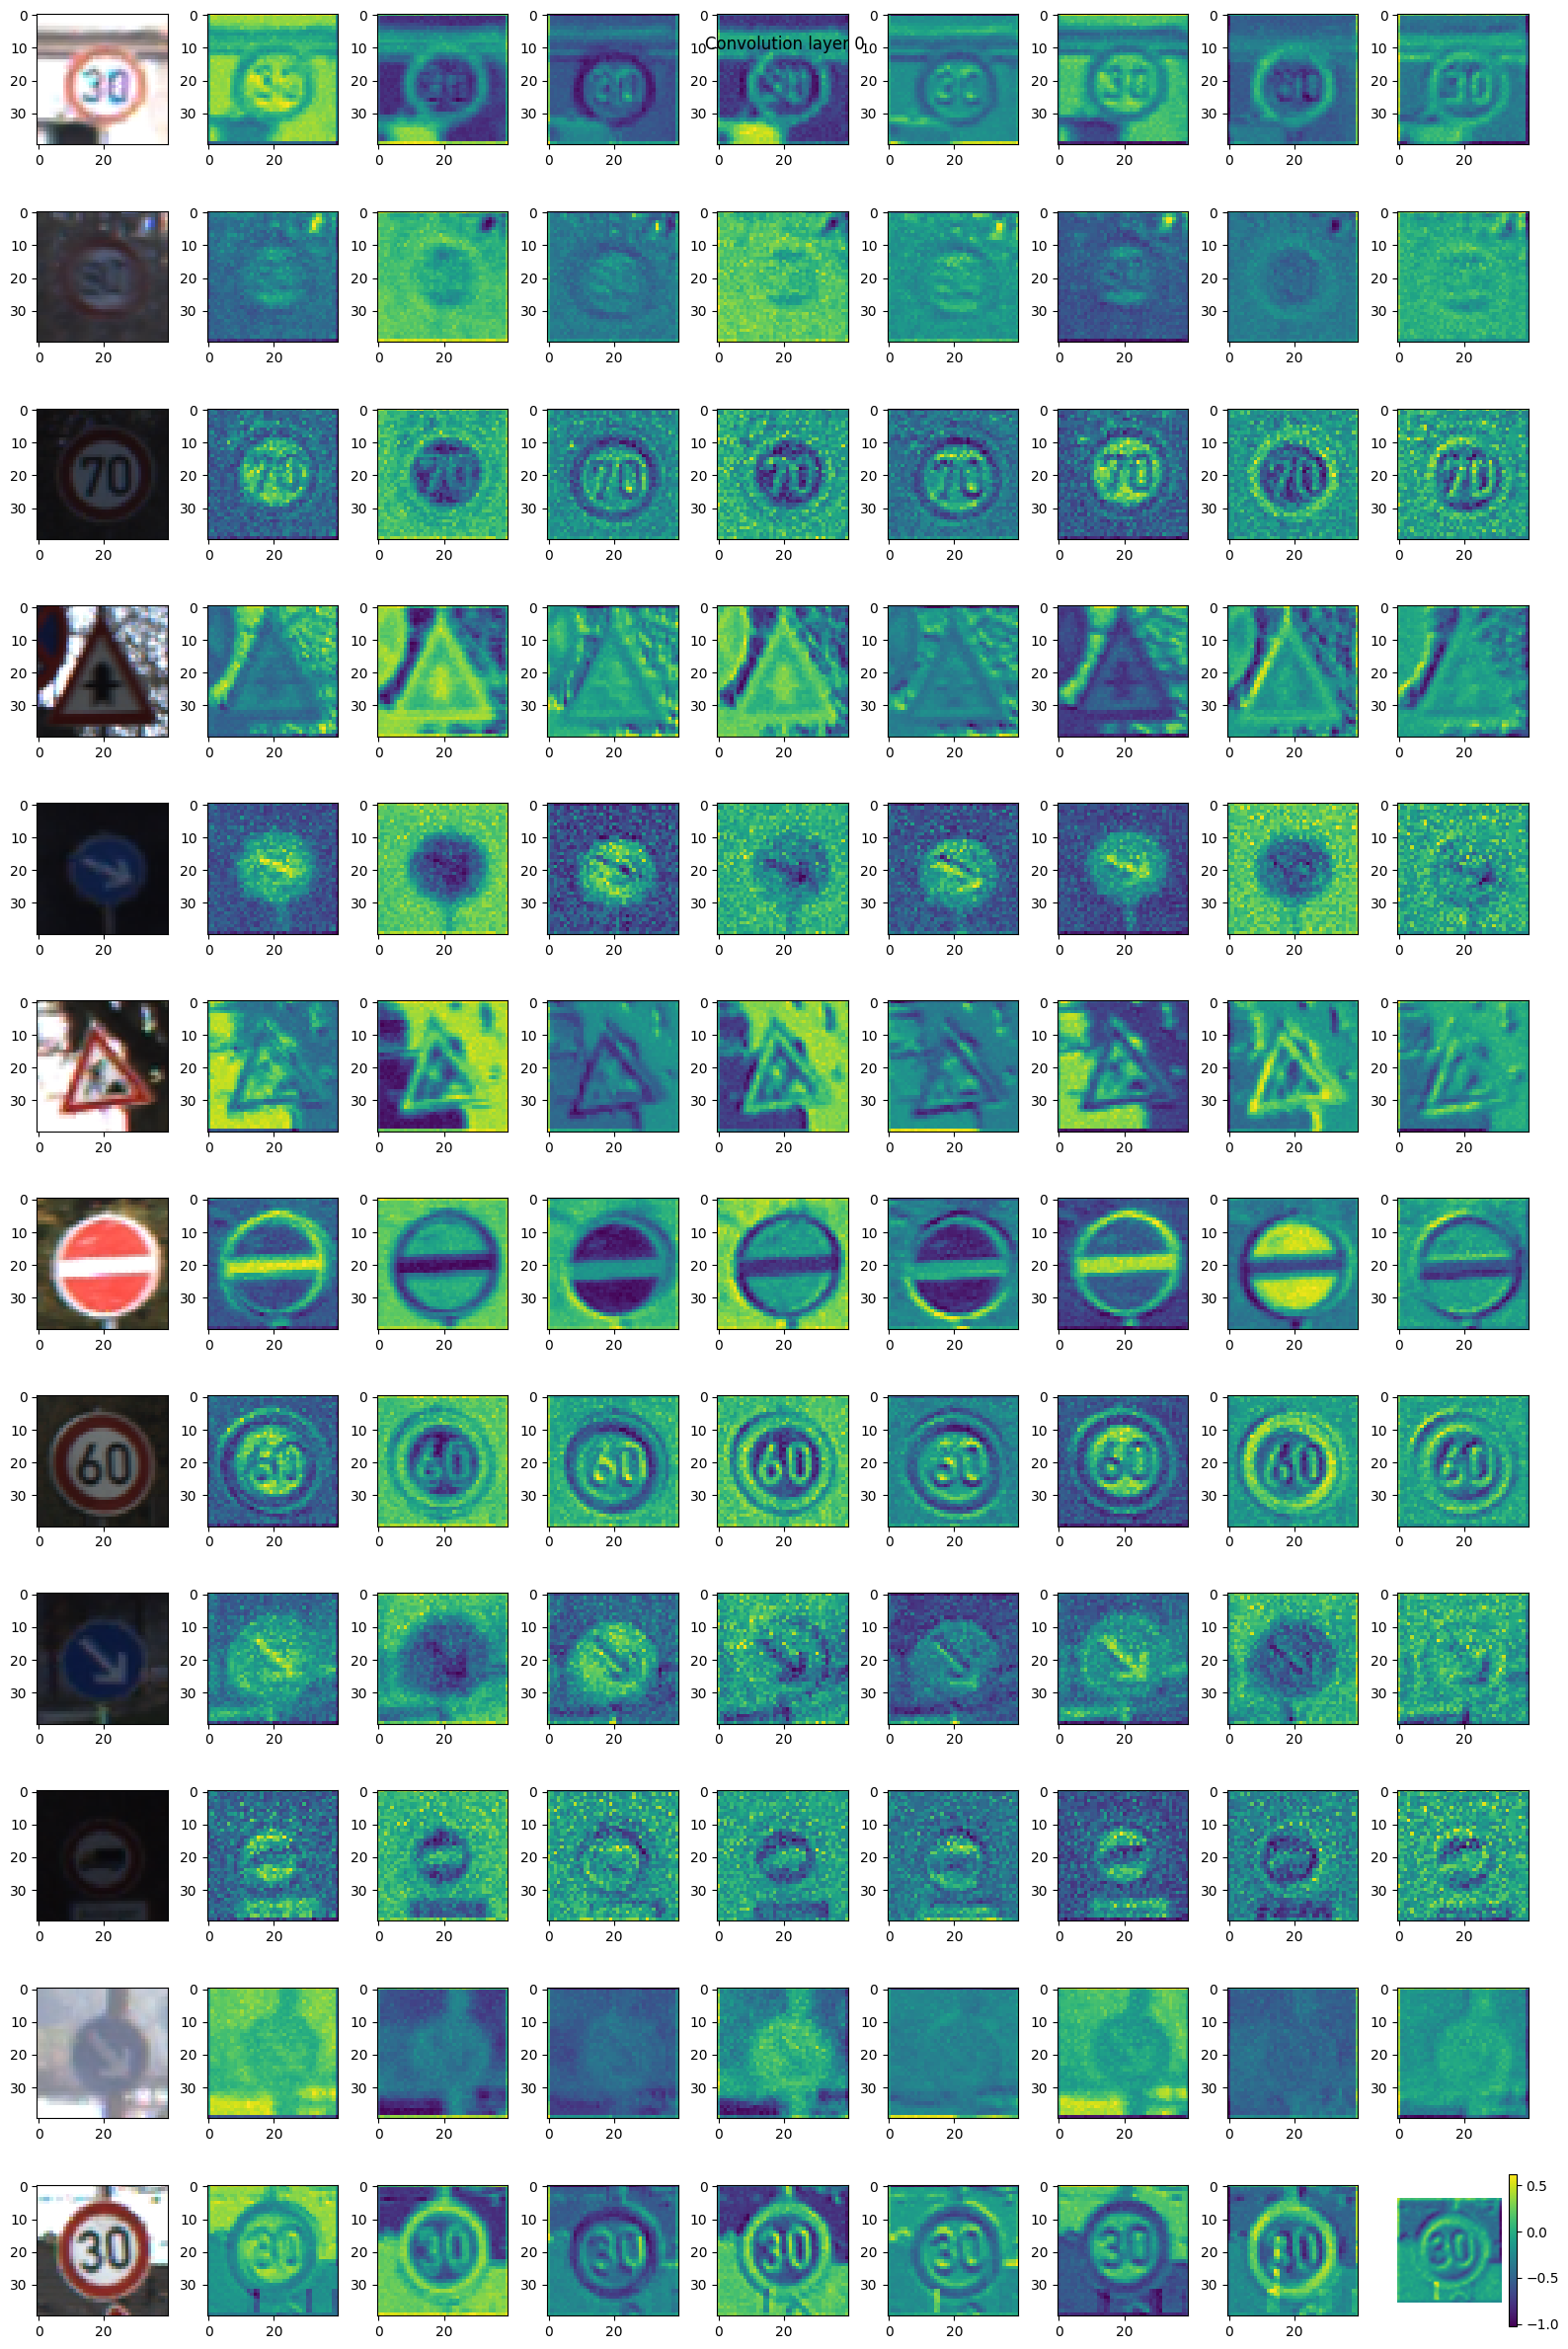

In [122]:
cnn_with_pooling.plot_feature_map(images, num_kernels=8)

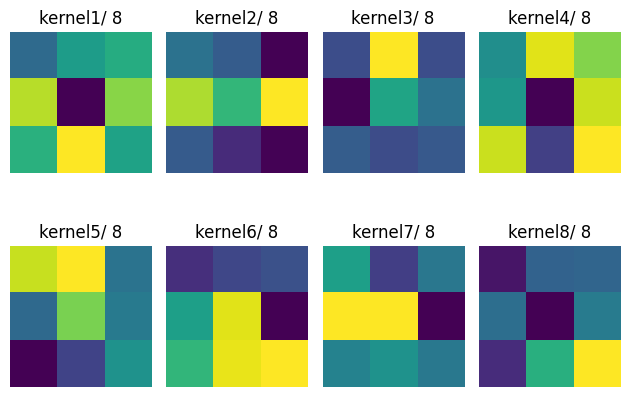

In [64]:
cnn_with_pooling.plot_kernels(8)

****using two conv layers without pooling****

In [129]:
cnnn = CNN(
    Conv(32, kernel_shape=(3, 3, 3)),
    Conv(16, kernel_shape=(3, 3, 32)),
    Flatten(),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(num_classes, Layer.Softmax),
    input_shape=(H, W, C)
)

[INFO] model parameters initialized successfully !


In [131]:
cnn = CNN(
    Conv(32, kernel_shape=(3, 3, 3), activation=Layer.ReLU),
    Conv(16, kernel_shape=(3, 3, 32), activation=Layer.ReLU),
    Flatten(),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(num_classes, Layer.Softmax),
    input_shape=(H, W, C)
)

[INFO] model parameters initialized successfully !


In [132]:
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=4,
    batch_size=32,
    learning_rate=0.001,
    class_weights=s_class_weights
)

100%|██████████| 856/856 [05:35<00:00,  2.55it/s]


[INFO] epoch 1/4 accuracy: 71.87500000 | val_accuracy: 59.33356001


100%|██████████| 856/856 [05:36<00:00,  2.55it/s]


[INFO] epoch 2/4 accuracy: 81.25000000 | val_accuracy: 75.79054743


100%|██████████| 856/856 [05:36<00:00,  2.54it/s]


[INFO] epoch 3/4 accuracy: 81.25000000 | val_accuracy: 82.82896974


100%|██████████| 856/856 [05:37<00:00,  2.54it/s]


[INFO] epoch 4/4 accuracy: 87.50000000 | val_accuracy: 88.98333900


In [237]:
a = 3400
b = a + 12
images = x_test[a:b]
labels = y_test[a:b]

<Figure size 2000x800 with 0 Axes>

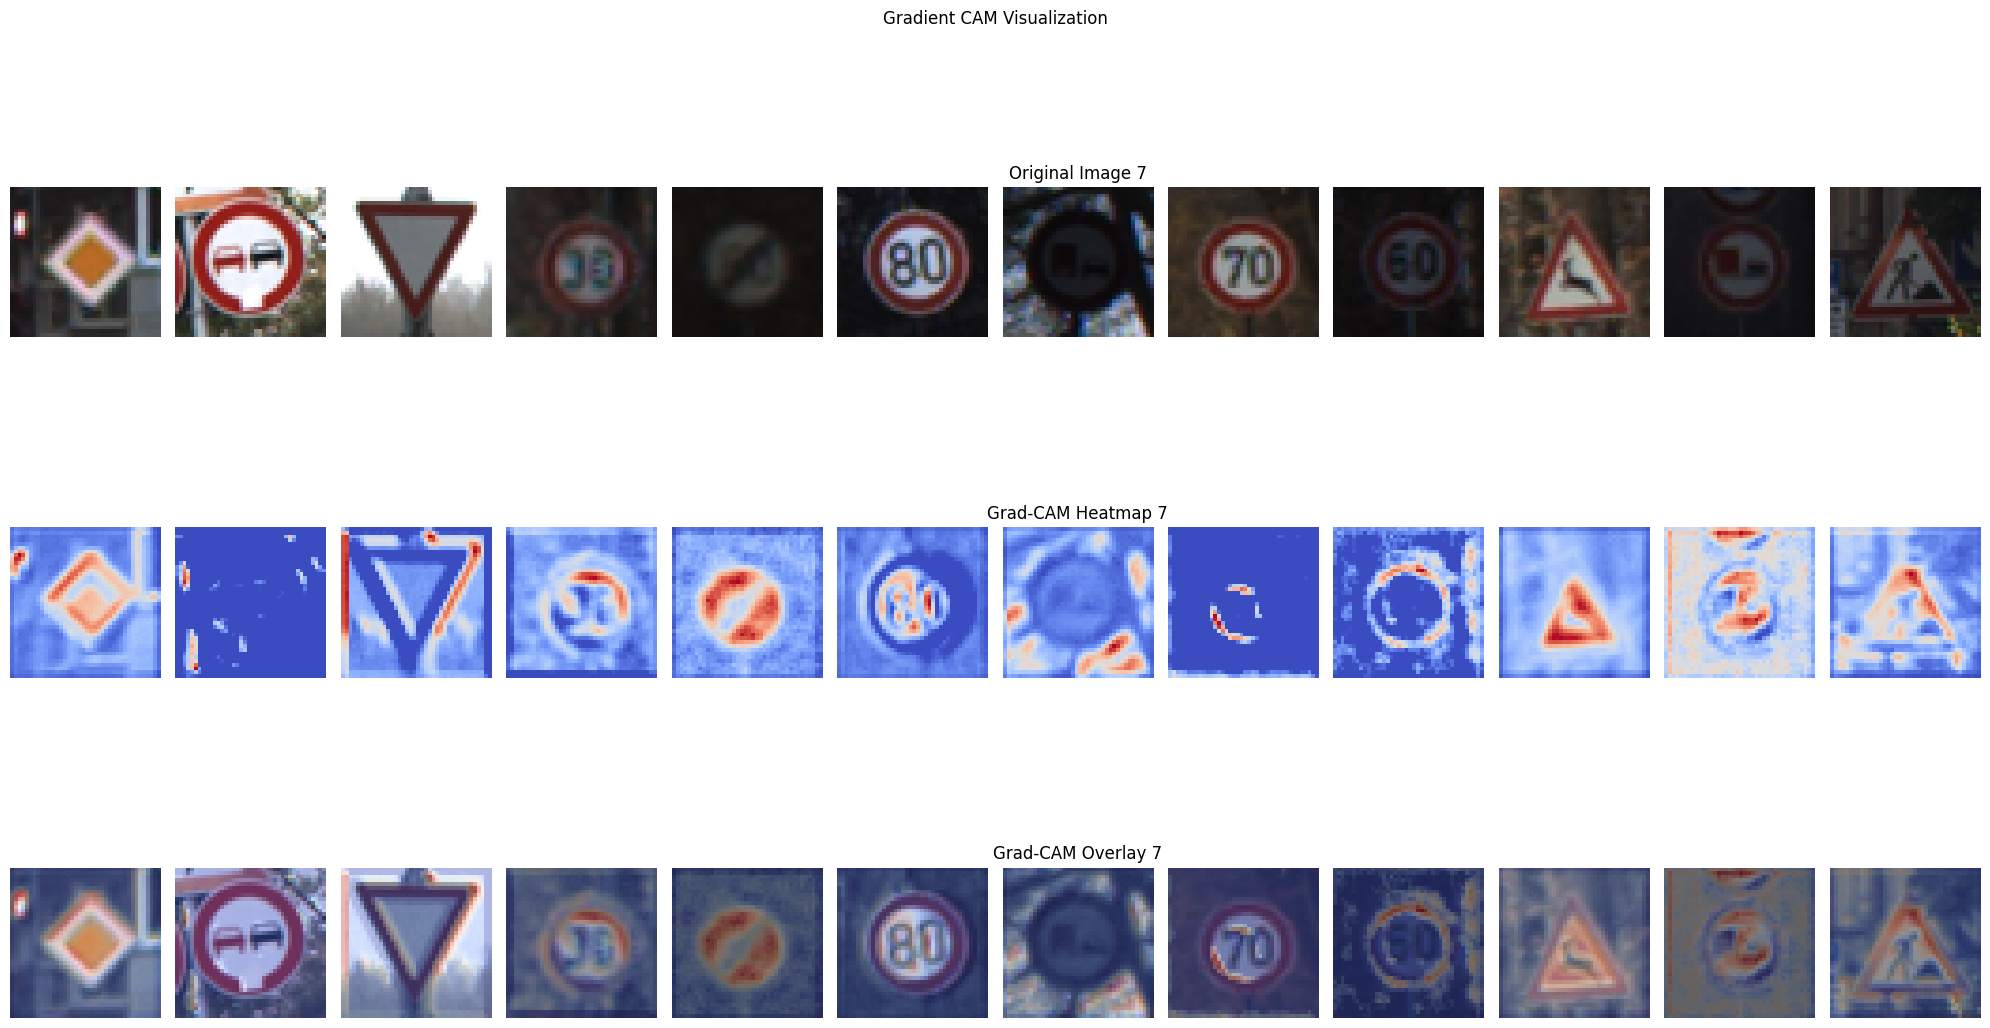

In [256]:
cnn.grad_cam(images, labels, layer_index=1, cmap="coolwarm")

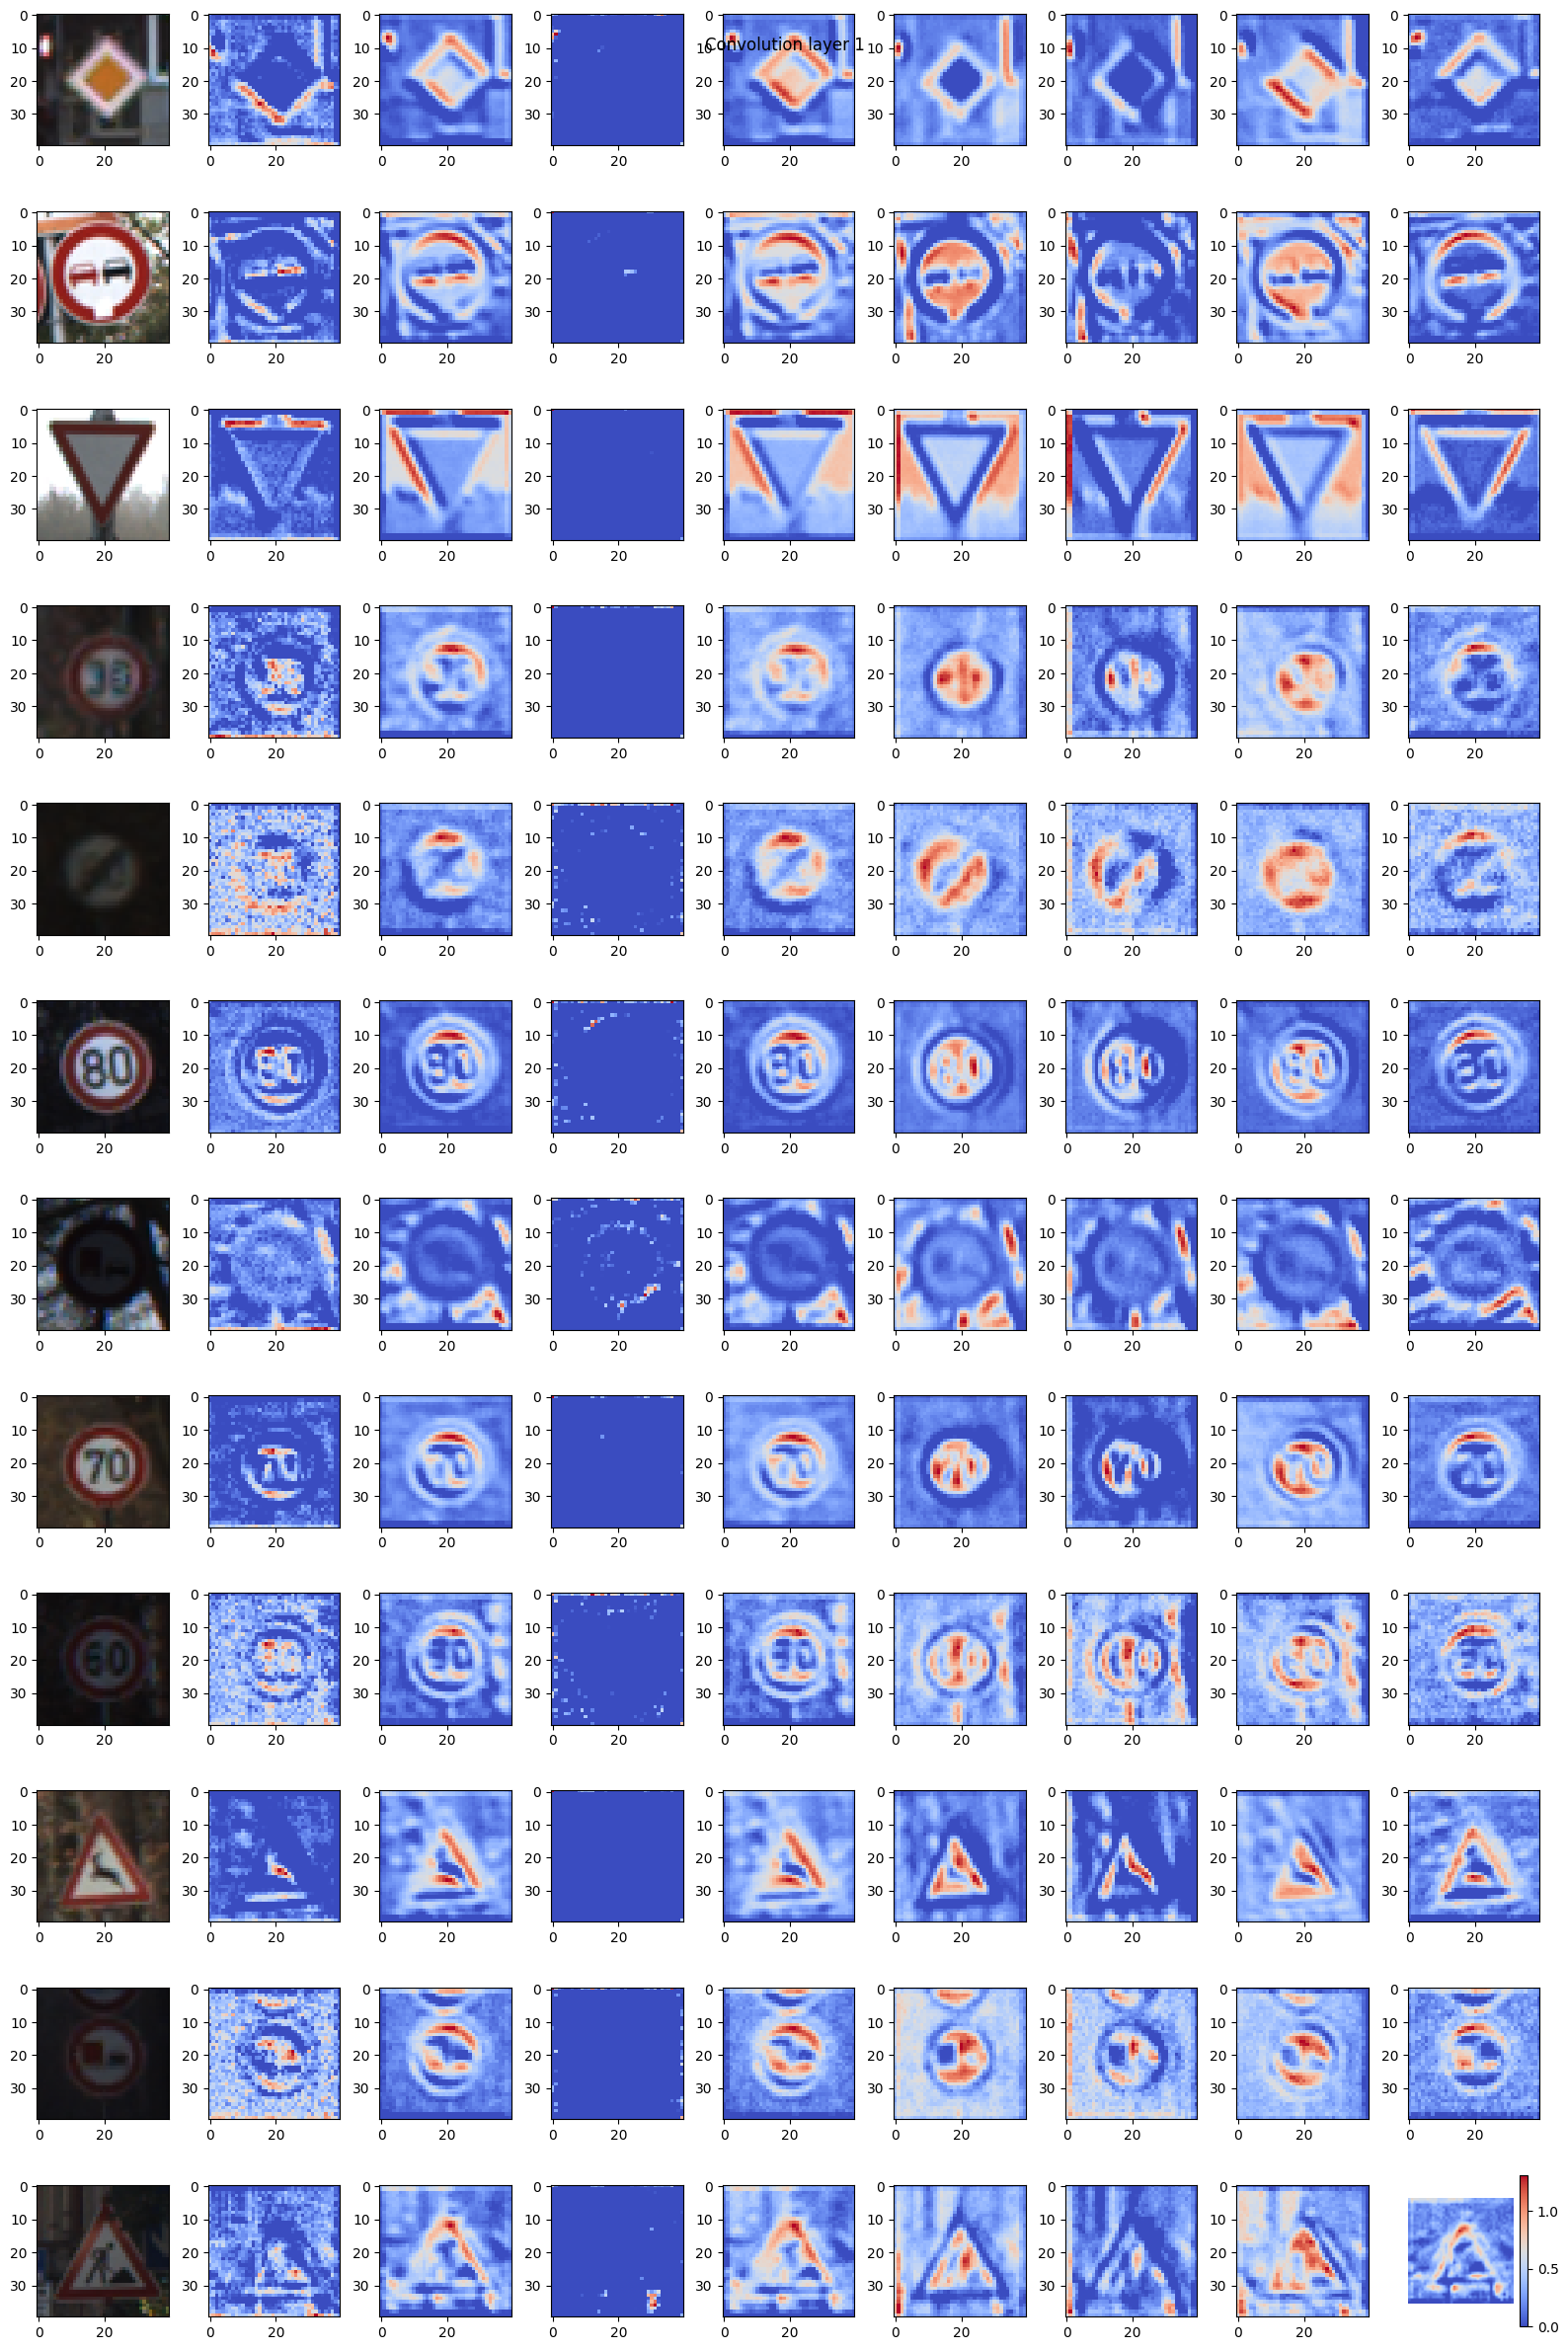

In [249]:
cnn.plot_feature_map(images, layer_index=1, num_kernels=8, cmap="coolwarm")

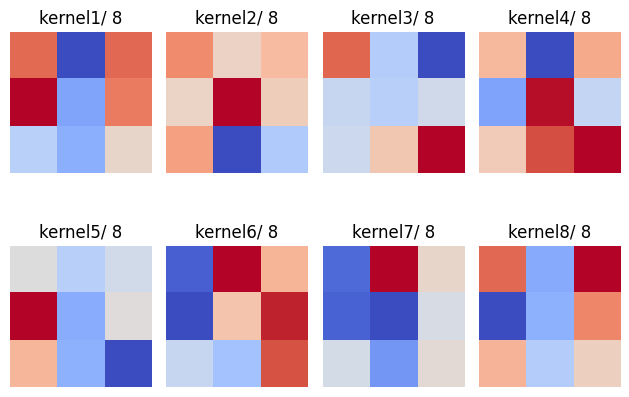

In [250]:
cnn.plot_kernels(8, layer_index=1, cmap="coolwarm")

## CIFAR 10

### Data

In [13]:
CIFAR10_path = '/kaggle/input/cifar10-classification-image'
path = CIFAR10_path
os.listdir(path)

['cifar10']

In [14]:
path = os.path.join(path, "cifar10")
os.listdir(path)

['test', 'train']

In [15]:
train_path = os.path.join(path, 'train')
test_path = os.path.join(path, 'test')
len(os.listdir(os.path.join(train_path, "cat"))), len(os.listdir(os.path.join(test_path, "cat")))

(5000, 1000)

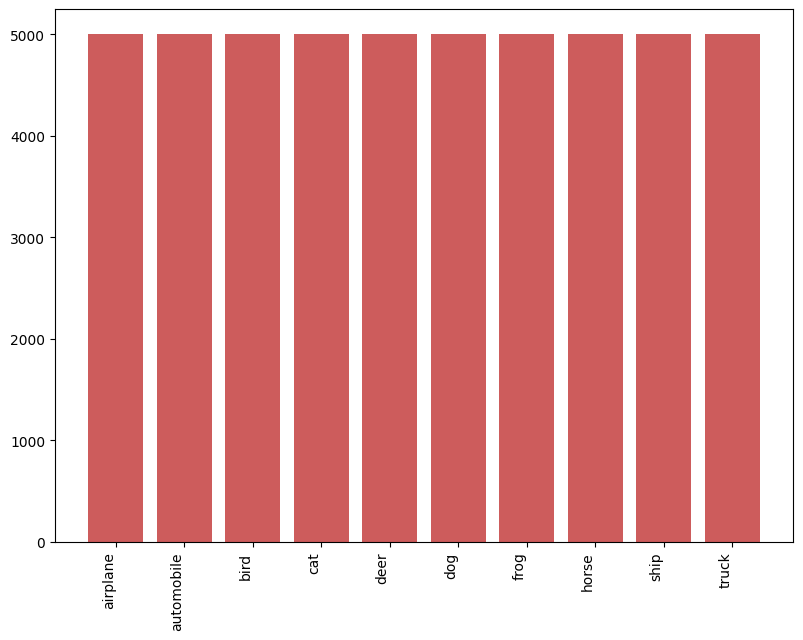

In [16]:
plot_classes_distribution(train_path)

In [17]:
H = W = 32
C = 3
num_classes = len(os.listdir(train_path))
x_train, y_train = load_data(train_path)
# print(len(os.listdir(train_path)))
x_test, y_test = load_data(test_path)

# x_train, y_train, x_test, y_test = split(x, y, ratio=0.7)
x_test, y_test, x_val, y_val = split(x_test, y_test, ratio=0.5)

100%|██████████| 10/10 [00:55<00:00,  5.60s/it]


In [18]:
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((50000, 32, 32, 3),
 (5000, 32, 32, 3),
 (5000, 32, 32, 3),
 (50000, 10),
 (5000, 10),
 (5000, 10))

In [19]:
np.argmax(y_train[:12], axis=1)

array([7, 3, 3, 1, 0, 1, 0, 8, 0, 7, 8, 6])

In [20]:
num_classes

10

### Model

In [37]:
cnn = CNN(
    Conv(32, kernel_shape=(3, 3, 3), activation=Layer.ReLU),
    # Pool(pool_shape=(2, 2)),
    Conv(16, kernel_shape=(3, 3, 32), activation=Layer.ReLU),
    Conv(8, kernel_shape=(3, 3, 16), activation=Layer.ReLU),
    # Pool(pool_shape=(2, 2)),
    Flatten(),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(num_classes, Layer.Softmax),
    input_shape=(H, W, C)
)
# cnn.layers[1].kernels *= 4e-2
# cnn.layers[2].kernels *= 2e-2

[INFO] model parameters initialized successfully !


In [38]:
max_threshold = 400

# warm-up phase
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1,
    batch_size=32,
    learning_rate=0.001,
    conv_grad_norm_threshold=80,
    fc_grad_norm_threshold=200
)

 20%|█▉        | 308/1561 [01:51<07:31,  2.78it/s]

Conv nan


 33%|███▎      | 510/1561 [03:04<06:24,  2.74it/s]

Conv nan


 93%|█████████▎| 1449/1561 [08:44<00:40,  2.74it/s]

Conv nan


100%|██████████| 1561/1561 [09:24<00:00,  2.76it/s]


[INFO] epoch 1/1 accuracy: 50.00000000 | val_accuracy: 37.50000000


In [39]:
# post warm-up phase
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1,
    batch_size=64,
    learning_rate=0.0004,
)

 46%|████▋     | 362/780 [03:49<04:24,  1.58it/s]

Conv nan


100%|██████████| 780/780 [08:14<00:00,  1.58it/s]


[INFO] epoch 1/1 accuracy: 28.12500000 | val_accuracy: 40.04000000


In [40]:
# post warm-up phase
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1,
    batch_size=32,
    learning_rate=0.0007,
)

  4%|▍         | 60/1561 [00:21<08:59,  2.78it/s]

Conv nan


  4%|▍         | 61/1561 [00:21<08:59,  2.78it/s]

Conv nan


  5%|▍         | 75/1561 [00:26<08:53,  2.79it/s]

...

Conv nan


 97%|█████████▋| 1516/1561 [09:01<00:16,  2.80it/s]

Conv nan


100%|██████████| 1561/1561 [09:17<00:00,  2.80it/s]


[INFO] epoch 1/1 accuracy: 50.00000000 | val_accuracy: 41.42000000


In [41]:
# post warm-up phase
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=2,
    batch_size=32,
    learning_rate=0.001,
)

  4%|▍         | 67/1561 [00:23<08:47,  2.83it/s]

Conv nan


  5%|▌         | 85/1561 [00:30<08:44,  2.81it/s]

Conv nan


  9%|▉         | 147/1561 [00:52<08:21,  2.82it/s]

...

Conv nan


 91%|█████████ | 1422/1561 [08:23<00:49,  2.82it/s]

Conv nan


100%|██████████| 1561/1561 [09:13<00:00,  2.82it/s]


[INFO] epoch 2/2 accuracy: 56.25000000 | val_accuracy: 45.20000000


In [42]:
# post warm-up phase
cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=2,
    batch_size=64,
    learning_rate=0.0004,
)

 57%|█████▋    | 443/780 [04:38<03:31,  1.59it/s]

Conv nan


100%|██████████| 780/780 [08:10<00:00,  1.59it/s]


[INFO] epoch 1/2 accuracy: 35.93750000 | val_accuracy: 47.38000000


 94%|█████████▍| 736/780 [07:42<00:27,  1.58it/s]

Conv nan


100%|██████████| 780/780 [08:10<00:00,  1.59it/s]


[INFO] epoch 2/2 accuracy: 35.93750000 | val_accuracy: 47.54000000


In [45]:
a = 0
b = a + 12
images = x_test[a:b]
labels = y_test[a:b]

<Figure size 2000x800 with 0 Axes>

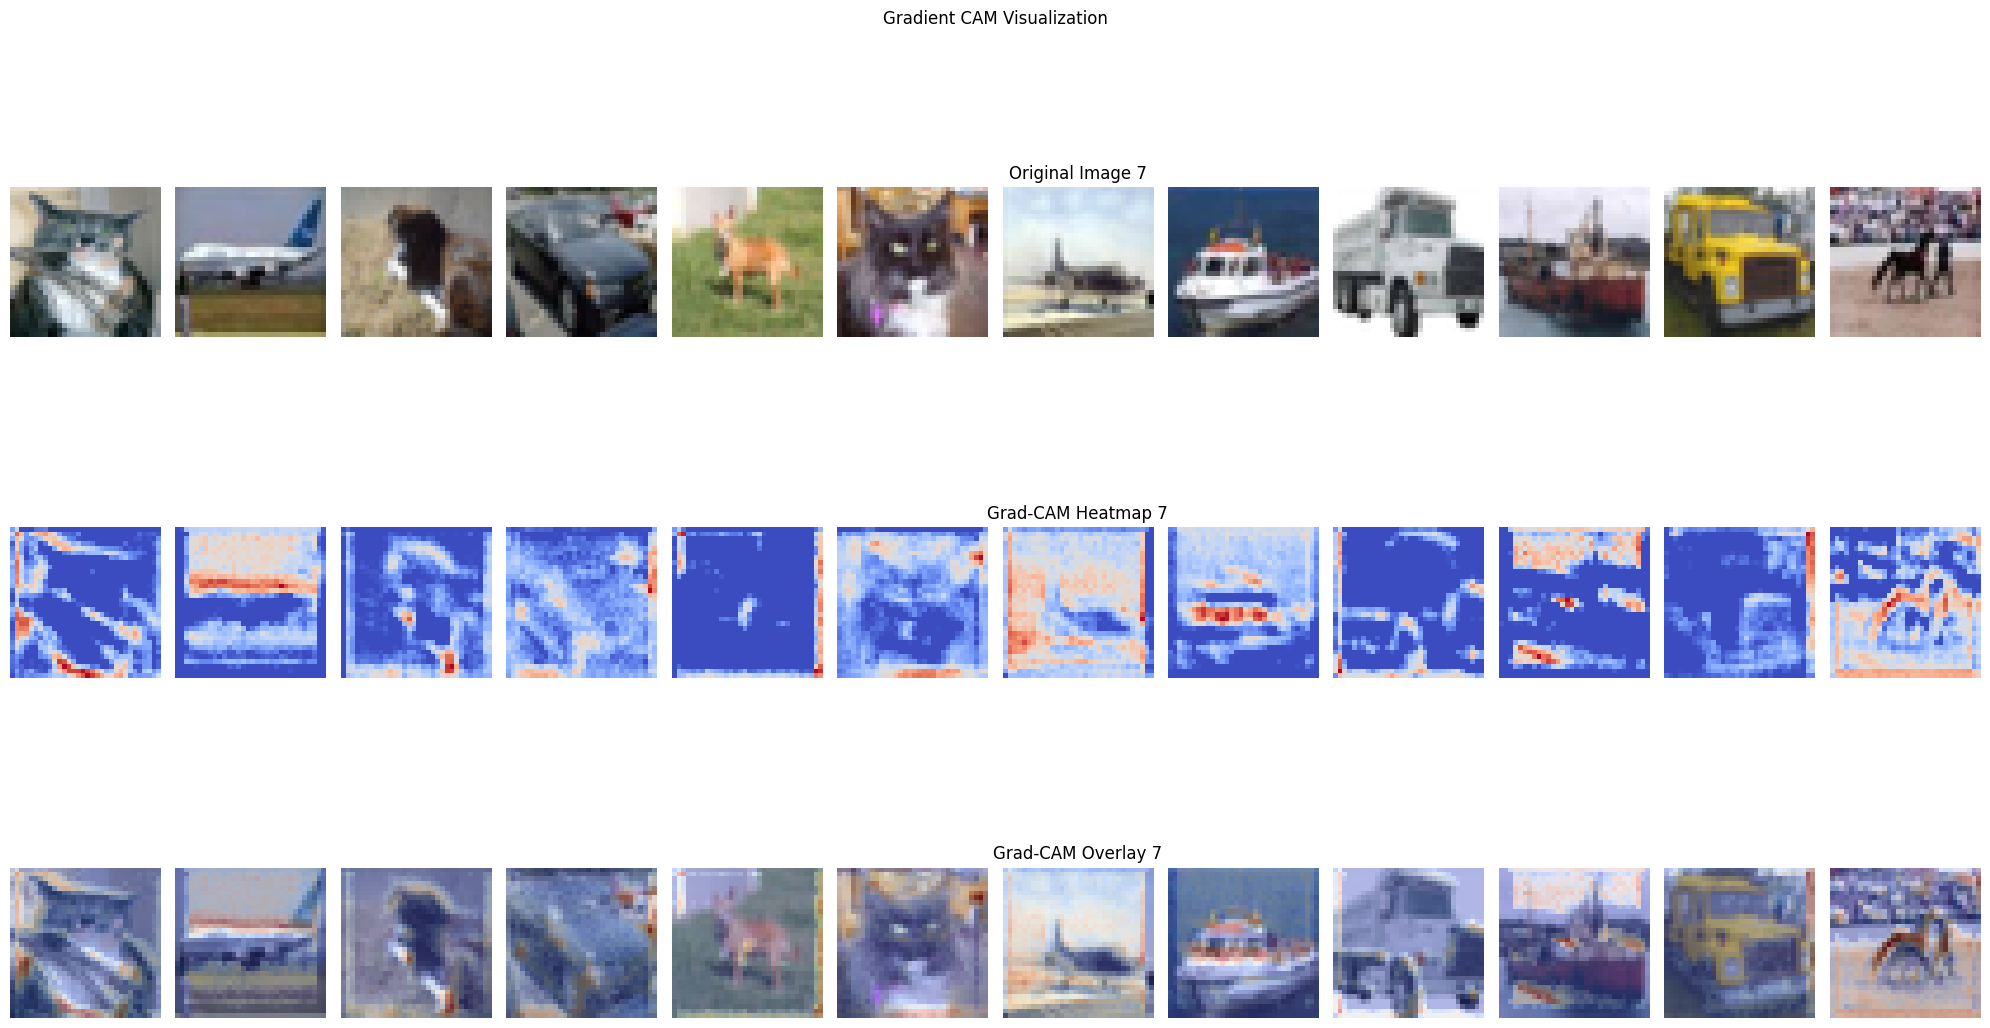

In [51]:
cnn.grad_cam(images, labels, layer_index=2, cmap="coolwarm")

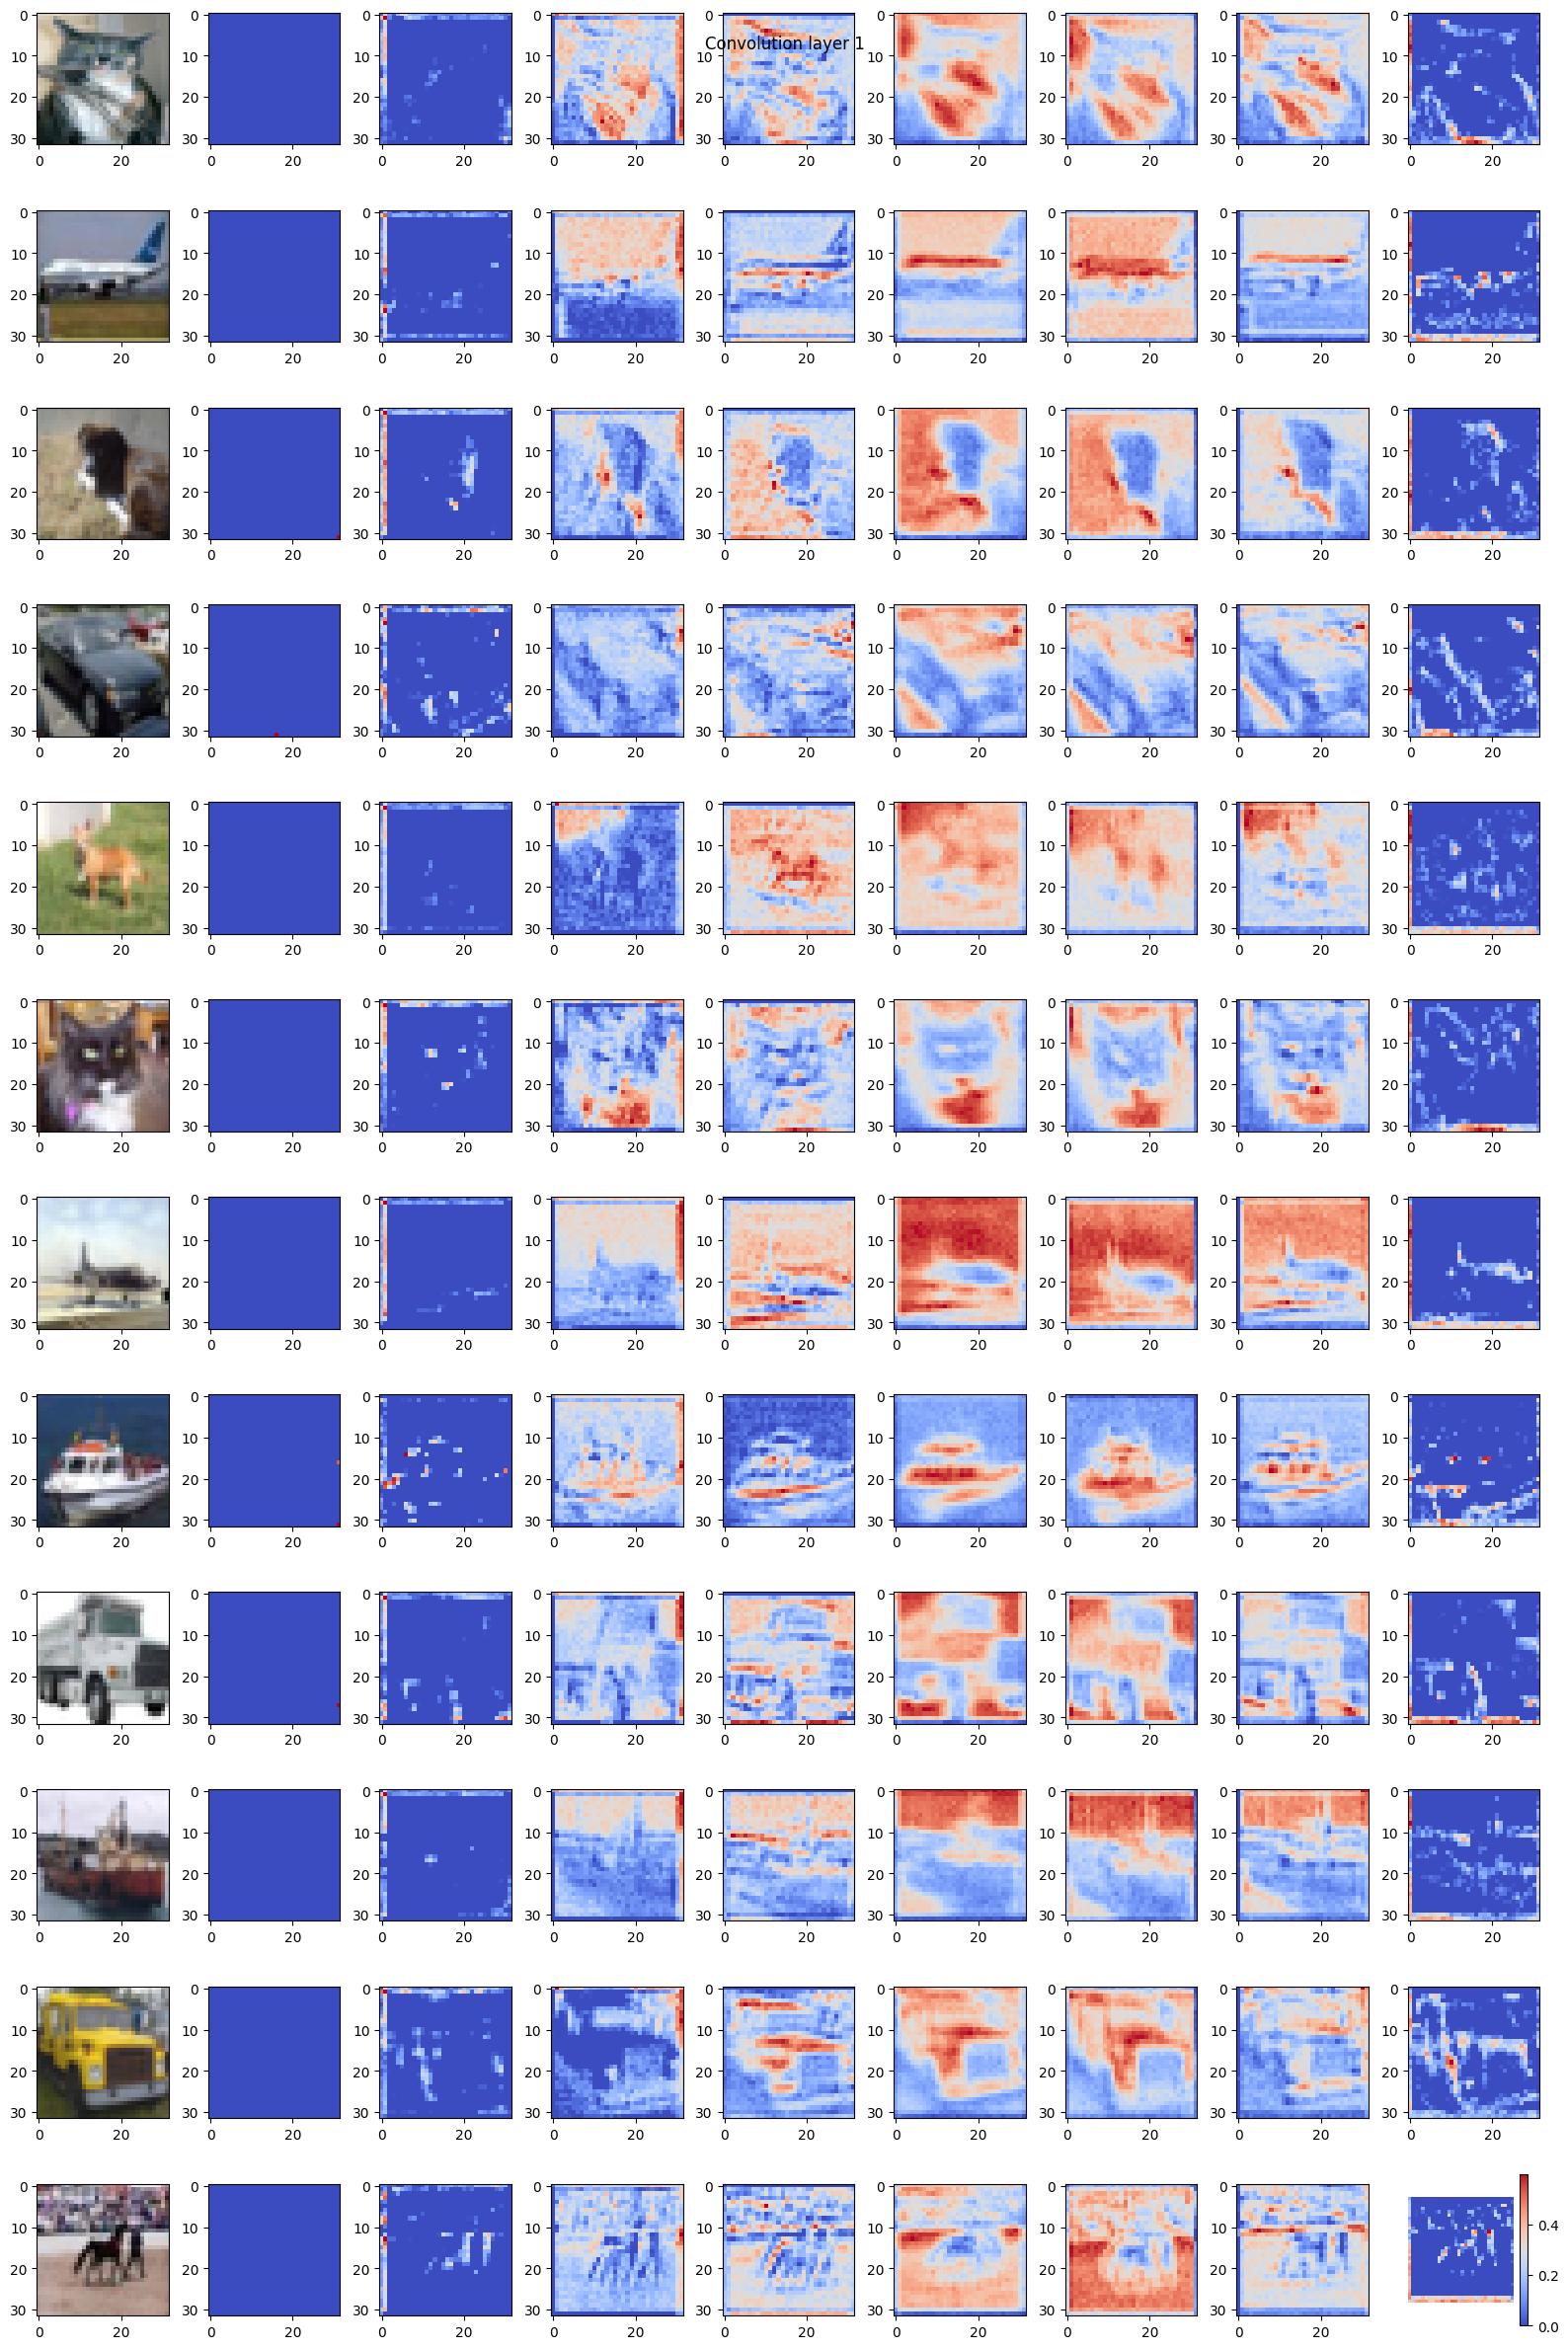

In [50]:
cnn.plot_feature_map(images, layer_index=1, num_kernels=8, cmap="coolwarm")

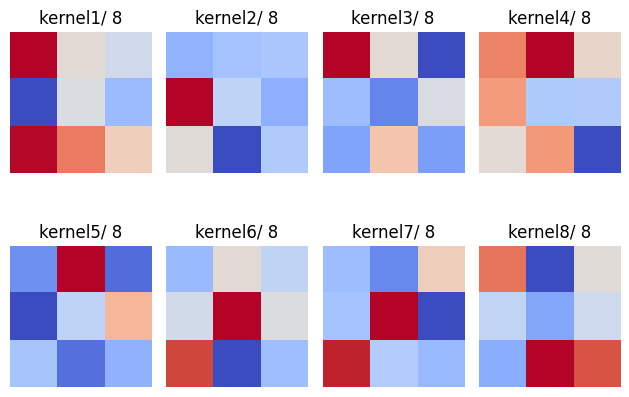

In [52]:
cnn.plot_kernels(8, layer_index=1, cmap="coolwarm")

## Fashion MNIST Data Set

In [94]:
path = "/kaggle/input/fashion-mnist-png"
os.listdir(path)

['test', 'train']

In [95]:
train_path = os.path.join(path, 'train')
test_path = os.path.join(path, 'test')
len(os.listdir(train_path)), len(os.listdir(test_path))

(10, 10)

In [96]:
os.listdir(train_path)

['7', '2', '5', '8', '0', '3', '1', '4', '9', '6']

In [97]:
for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)
    print(label, len(os.listdir(label_path)))
print("\n\n")
for label in os.listdir(test_path):
    label_path = os.path.join(test_path, label)
    print(label, len(os.listdir(label_path)))

7 6000
2 6000
5 6000
8 6000
0 6000
3 6000
1 6000
4 6000
9 6000
6 6000



7 1000
2 1000
5 1000
8 1000
0 1000
3 1000
1 1000
4 1000
9 1000
6 1000


6000
(28, 28)


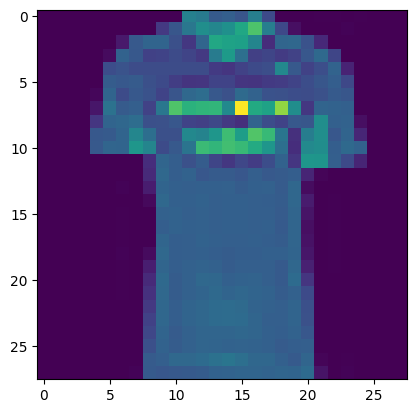

In [98]:
label_path = os.path.join(train_path, "0")
image_file = os.listdir(label_path)[0]
image_path = os.path.join(label_path, image_file)
print(len(os.listdir(label_path)))
image = Image.open(image_path)
print(np.array(image).shape)
plt.imshow(image)

In [99]:
H = W = 28
C = 1
num_classes = len(os.listdir(train_path))
x_train, y_train = load_data(train_path)

x_test, y_test = load_data(test_path)

x_test, y_test, x_val, y_val = split(x_test, y_test, ratio=0.5)

100%|██████████| 10/10 [00:55<00:00,  5.55s/it]


In [110]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)

In [111]:
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((60000, 28, 28, 1),
 (5000, 28, 28, 1),
 (5000, 28, 28, 1),
 (60000, 10),
 (5000, 10),
 (5000, 10))

In [112]:
np.argmax(y_train[:12], axis=1)

array([8, 1, 4, 1, 5, 7, 7, 1, 1, 5, 6, 2])

In [116]:
cnn = CNN(
    Conv(16, kernel_shape=(3, 3, 1), activation=Layer.ReLU),
    Conv(8, kernel_shape=(3, 3, 16), activation=Layer.ReLU),
    Flatten(),
    Fully_Connected(128, Layer.ReLU),
    Fully_Connected(num_classes, Layer.Softmax),
    input_shape=(H, W, C)
)

[INFO] model parameters initialized successfully !


In [117]:
max_threshold = float('inf')

cnn.optimize(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=2,
    batch_size=32,
    learning_rate=0.001,
)

100%|██████████| 1874/1874 [02:40<00:00, 11.71it/s]


[INFO] epoch 1/2 accuracy: 75.00000000 | val_accuracy: 82.92000000


100%|██████████| 1874/1874 [02:40<00:00, 11.70it/s]


[INFO] epoch 2/2 accuracy: 81.25000000 | val_accuracy: 84.72000000


In [120]:
a = 0
b = a + 12
images = x_test[a:b]
labels = y_test[a:b]

<Figure size 2000x800 with 0 Axes>

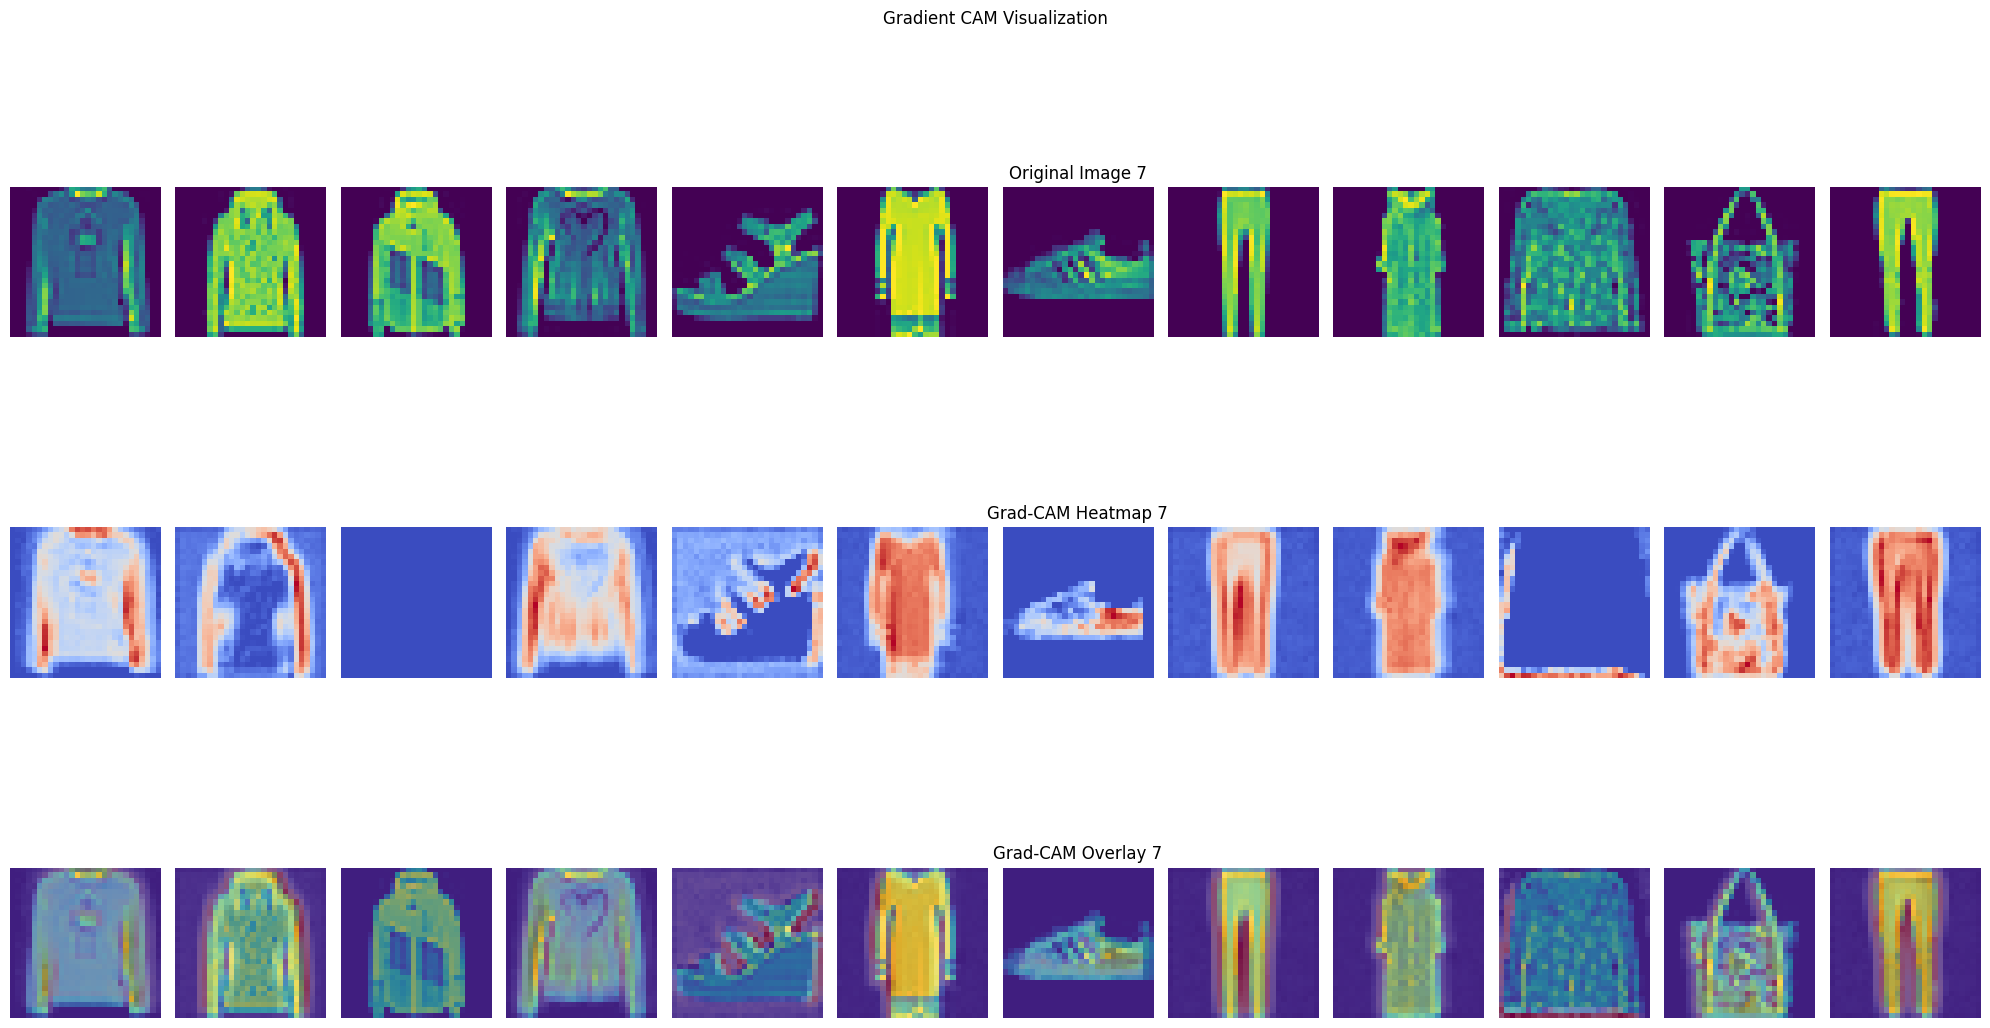

In [121]:
cnn.grad_cam(images, labels, layer_index=1, cmap="coolwarm")

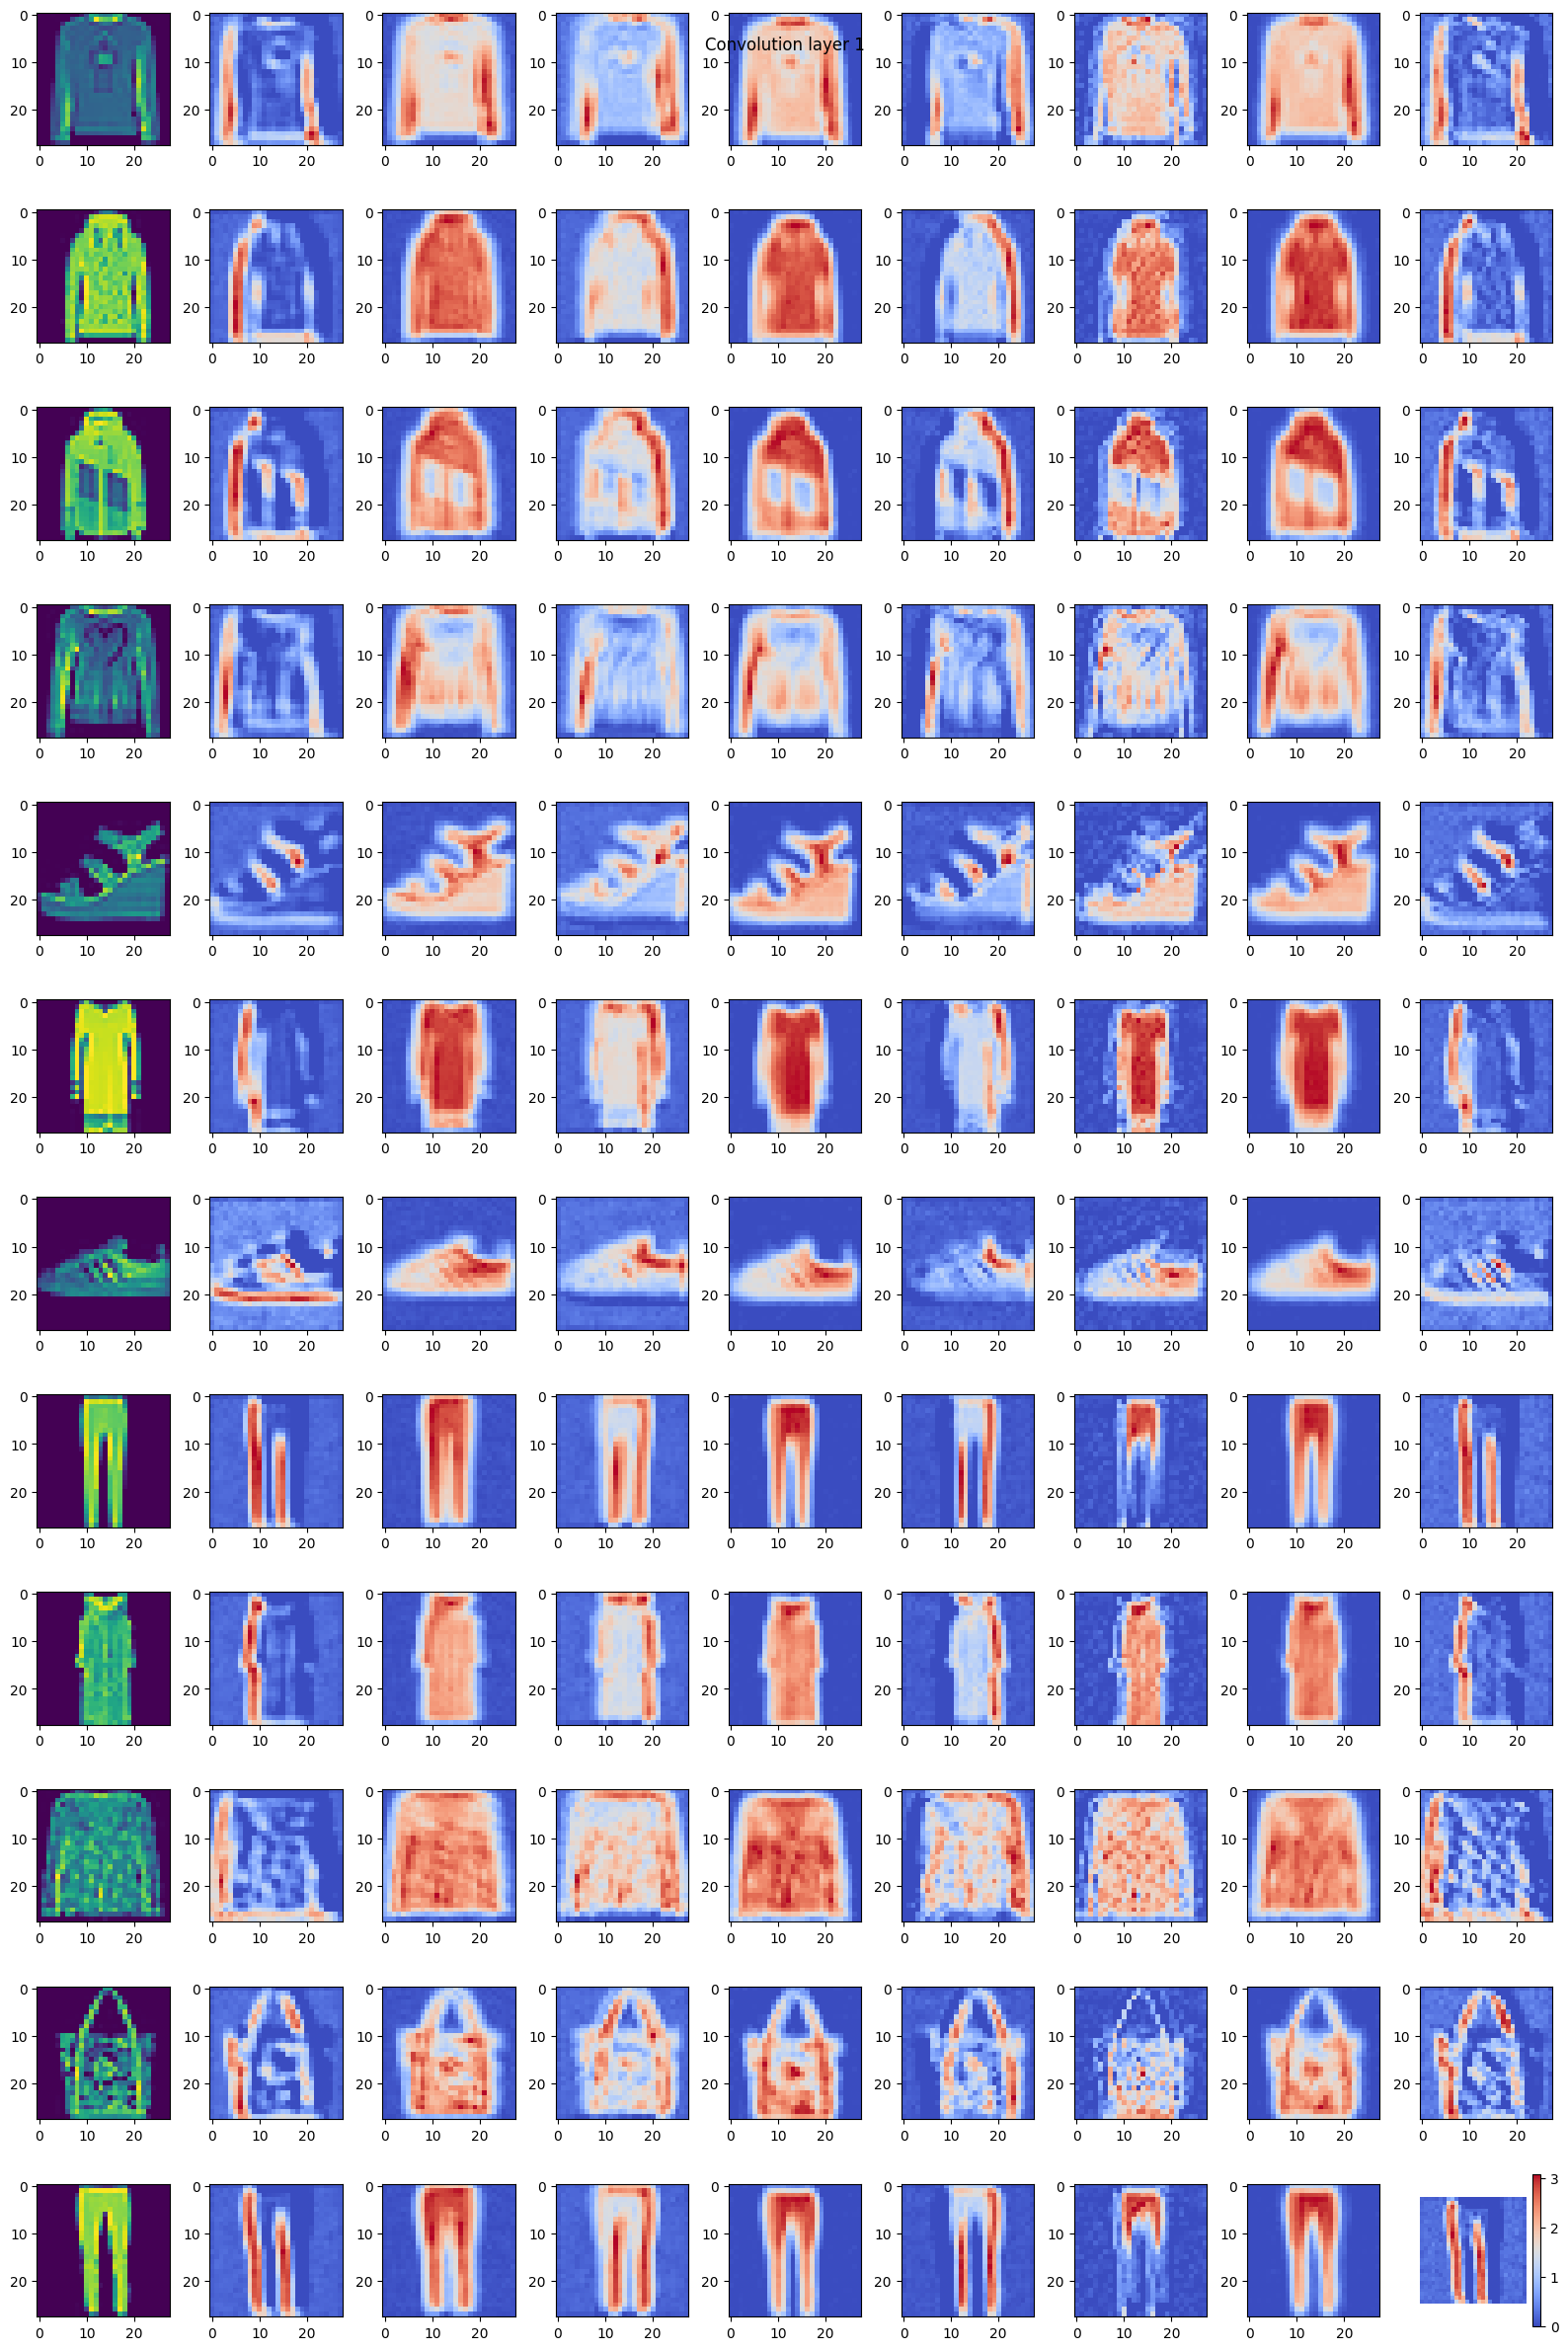

In [122]:
cnn.plot_feature_map(images, layer_index=1, num_kernels=8, cmap="coolwarm")

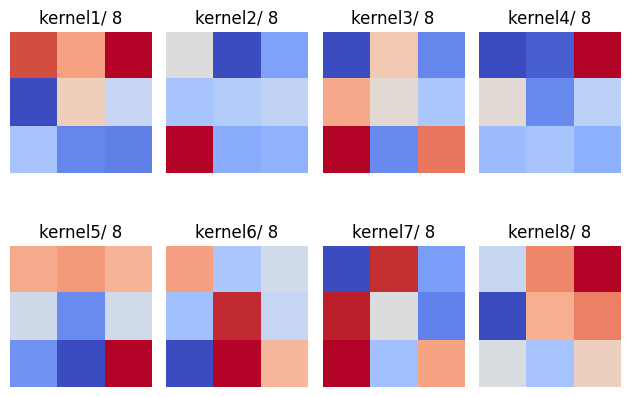

In [123]:
cnn.plot_kernels(8, layer_index=1, cmap="coolwarm")